In [ ]:
import logging
import os
from pathlib import Path
import sys
import warnings

from dotenv import load_dotenv
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd() / "src"))
logging.getLogger().addHandler(logging.StreamHandler(sys.stdout))
logging.getLogger().setLevel(logging.INFO)

from src.data.download import download_xenium_dataset
from src.scripts.analysis.regression_analysis import (
    compute_gene_spatial_stats,
    plot_top_spatial_genes,
)
from src.scripts.preprocessing.geometry import (
    build_polygons,
    close_polygon_if_needed,
    compute_cell_to_plaque_distances,
    filter_plaques,
    load_plaques,
    rename_centroid_columns,
)
from src.scripts.preprocessing.loaders import (
    combine_cells_and_expression,
    load_cells_table,
    load_expression_matrix,
)
from src.scripts.preprocessing.normalization import pydeseq2_normalize_global
from src.scripts.preprocessing.partition import (
    DEFAULT_META_COLS,
    compute_pigs_zscores,
    compute_weird_gene_scores,
    plot_gene_distributions,
    plot_weird_gene_panels,
    split_meta_vs_genes,
    summarize_genes,
)
from src.scripts.preprocessing.plaque_distance import (
    plot_cell_to_plaque_map_visible,
)
from src.scripts.preprocessing.qc import (
    filter_cells,
    plot_qc_distributions,
)
from src.scripts.preprocessing.spatial_trends import (
    assign_distance_bins,
    mean_expression_by_bin,
    plot_gene_trends,
    plot_mean_heatmap,
)
from src.scripts.vizualisation.plots import analyze_plaque_distance, hist1d, plot_plaques
from src.utils.logging_utils import logger

warnings.filterwarnings("ignore")
load_dotenv()

True

# Data Preprocessing

In [ ]:
# 1. Download the data if not already downloaded
url = "https://cf.10xgenomics.com/samples/xenium/1.4.0/Xenium_V1_FFPE_TgCRND8_17_9_months/Xenium_V1_FFPE_TgCRND8_17_9_months_outs.zip"
BASE_XENIUM_DIR = os.environ["BASE_XENIUM_DIR"]
PATH_TO_DATA_FOLDER = "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months"
output_dir = f"{BASE_XENIUM_DIR}/Xenium_V1_FFPE_TgCRND8_17_9_months_outs"
xenium_path = download_xenium_dataset(url, output_dir)

# 2. Load the data
cells_path = f"{xenium_path}/cells.parquet"
expr_path = f"{xenium_path}/cell_feature_matrix.h5"
cells_df = load_cells_table(cells_path)
adata = load_expression_matrix(expr_path, False)
combined_df = combine_cells_and_expression(cells_df, adata, f"{PATH_TO_DATA_FOLDER}/combined.csv")

Dataset already downloaded in /Users/alexanders/Desktop/Downloads_Folder//Xenium_V1_FFPE_TgCRND8_17_9_months_outs, skipping.
Loading cells table from /Users/alexanders/Desktop/Downloads_Folder//Xenium_V1_FFPE_TgCRND8_17_9_months_outs/cells.parquet
Loaded 62268 cells with 10 columns
Loading expression matrix from /Users/alexanders/Desktop/Downloads_Folder//Xenium_V1_FFPE_TgCRND8_17_9_months_outs/cell_feature_matrix.h5
Loaded expression matrix: 62268 cells * 347 genes


In [ ]:
# 3. Partition columns into meta columns and gene features
num_cols = combined_df.select_dtypes(include=[np.number]).columns.tolist()
gene_cols = [c for c in num_cols if c not in DEFAULT_META_COLS]
meta, genes, info = split_meta_vs_genes(combined_df, meta_cols=DEFAULT_META_COLS)
logger.info(f"Numeric columns: {info['n_numeric']}")
logger.info(f"Gene feature columns: {info['n_genes']}")
logger.info(f"Sample gene columns: {list(genes.columns[:10])}")

Numeric columns: 356
Gene feature columns: 347
Sample gene columns: ['2010300C02Rik', 'Abca7', 'Acsbg1', 'Acta2', 'Acvrl1', 'Adamts2', 'Adamtsl1', 'Adgrl4', 'Aldh1a2', 'Aldh1l1']


Filtering cells below 5.0th percentile for transcript_counts and 5.0th percentile for cell_area and 5.0th percentile for nucleus_areaand 5.0th percentile for n_genesand removing cells with <=0 cell area / nucleus area / total number of nonzero genes
Computed thresholds: transcript_counts > 75.00, cell_area > 102.05 nucleus_area > 13.01 n_genes > 34.00
Retained 46069 / 53895 cells (85.5%)
Original: 62268 cells → Filtered: 46069 cells
Plotting QC distributions with cutoffs: transcripts > 102.00, area > 137.18


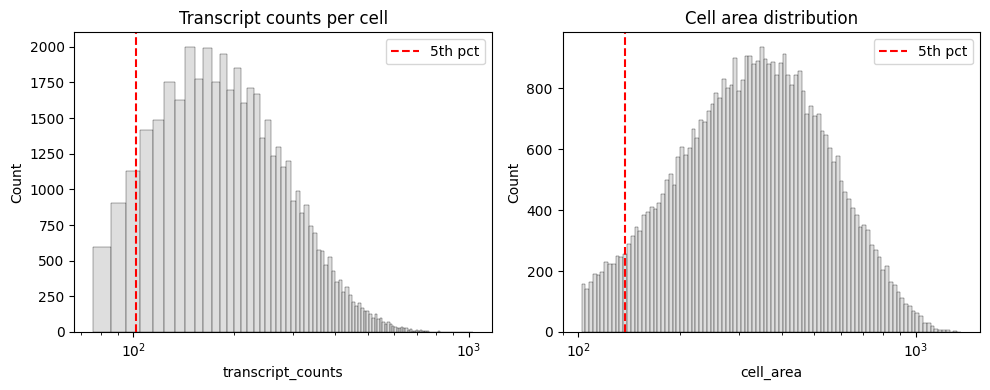

In [ ]:
# 4. Filter the cells with <=0 cell area / nucleus area / total number of nonzero genes
# Remove all cells under the5th percentile of transcript count / cell area / nucleus area / total number of nonzero genes
# TODO: the axi are wrong; update them and add nicer labels
filtered_combined_df = filter_cells(
    combined_df, transcript_q=0.05, area_q=0.05, nucleus_q=0.05, genes_q=0.05, gene_cols=gene_cols
)
filtered_combined_df = rename_centroid_columns(filtered_combined_df)
logger.info(
    f"Original: {cells_df.shape[0]} cells → Filtered: {filtered_combined_df.shape[0]} cells"
)
plot_qc_distributions(filtered_combined_df, transcript_q=0.05, area_q=0.05)

In [ ]:
# Normalize the data and merge it with the filtered cells
adata_normalized, size_factors = pydeseq2_normalize_global(adata, min_genes=20, apply_log1p=True)
combined_df_normalized = combine_cells_and_expression(
    filtered_combined_df[cells_df.columns],
    adata_normalized,
    f"{PATH_TO_DATA_FOLDER}/combined_normalized.csv",
)
combined_df = combine_cells_and_expression(
    filtered_combined_df[cells_df.columns], adata, f"{PATH_TO_DATA_FOLDER}/combined.csv"
)

🔄 Applying PyDESeq2 median-of-ratios normalization...
Converting to pandas DataFrame for PyDESeq2...
Input data: 62268 cells × 347 genes
Computing size factors using PyDESeq2...
PyDESeq2 returned all NaN size factors, falling back to custom implementation
Computing DESeq2-style size factors...
Computing geometric mean per gene (ignoring zeros)...
Computed geometric means for 347/347 genes
Using 347 genes with defined geometric means
Global median is 0, setting all size factors to 1.0
Size factors computed: median=1.000, range=[1.000, 1.000]
Applying log1p transformation for exploration...
✅ Log1p transformation applied
Size factors computed: median=1.000, range=[1.000, 1.000]
✅ PyDESeq2 normalization complete


In [ ]:
# 5. Load the plaque data, build valid polygons
PLAQUES_CSV = Path(f"{PATH_TO_DATA_FOLDER}/plaque_polygons.csv")
plaques_long = load_plaques(PLAQUES_CSV)
plaques_poly = build_polygons(plaques_long)
# 6. Load the brain polygon and ensure it is valid
BRAIN_CSV = Path(f"{PATH_TO_DATA_FOLDER}/brain_polygon.csv")
brain = (
    pd.read_csv(
        BRAIN_CSV, sep=",", header=None, skiprows=2, names=["name", "x", "y"], engine="python"
    )
    .assign(
        x=lambda d: pd.to_numeric(d["x"], errors="coerce"),
        y=lambda d: pd.to_numeric(d["y"], errors="coerce"),
    )
    .dropna(subset=["x", "y"])
    .reset_index(drop=True)
)
brain_xy = brain[["x", "y"]].to_numpy()
brain_geom = close_polygon_if_needed(brain_xy)

logger.info(
    f"plaques_long: {len(plaques_long):,} vertices | plaques_poly: {len(plaques_poly):,} polygons | brain polygon valid: {brain_geom.is_valid}"
)
display(plaques_long.head())
display(plaques_poly.head())

plaques_long: 161,308 vertices | plaques_poly: 1,938 polygons | brain polygon valid: True


,plaque_name,x,y,plaque_id
0,Selection 1,3420.774,4702.540,1
1,Selection 1,3422.074,4702.535,1
2,Selection 1,3422.073,4702.210,1
3,Selection 1,3422.398,4702.209,1
4,Selection 1,3422.396,4701.559,1


,plaque_id,geometry
0,1,"POLYGON ((3420.774 4702.54, 3422.074 4702.535,..."
1,2,"POLYGON ((3086.336 4693.312, 3087.311 4693.308..."
2,3,"POLYGON ((3495.805 4691.228, 3496.78 4691.225,..."
3,4,"POLYGON ((3515.948 4689.532, 3516.598 4689.53,..."
4,5,"POLYGON ((3017.087 4685.43, 3018.387 4685.425,..."


In [ ]:
# TODO: migrate to configs
ENFORCE_CONVEX = True
FILL_HOLES = True
REMOVE_NESTED = True
MERGE_OVERLAPS = True

plaques_poly = filter_plaques(
    plaques_poly,
    brain_geom,
    FILL_HOLES=FILL_HOLES,
    ENFORCE_CONVEX=ENFORCE_CONVEX,
    REMOVE_NESTED=REMOVE_NESTED,
    MERGE_OVERLAPS=MERGE_OVERLAPS,
)
display(plaques_poly.head())

{'n_final': 1828, 'polygons': 1828, 'multipolygons': 0, 'holes_present': 1, 'convex': 1803}


,geometry,plaque_id,isPolygon,isMultiPolygon,is_valid,has_holes,is_convex,area,centroid_x,centroid_y,in_brain
0,"POLYGON ((818.959 336.75, 817.984 336.754, 817...",1,True,False,True,False,True,8.765845,819.034449,338.558306,True
1,"POLYGON ((817.401 355.93, 817.075 355.606, 816...",2,True,False,True,False,True,28.410058,817.547747,359.493661,True
2,"POLYGON ((700.007 427.187, 700.004 426.212, 69...",3,True,False,True,False,True,15.314346,697.396075,426.938671,True
3,"POLYGON ((920.401 443.314, 920.072 442.015, 91...",4,True,False,True,False,True,11.037299,918.608001,443.470562,True
4,"POLYGON ((958.882 481.202, 960.507 481.196, 96...",5,True,False,True,False,True,133.495062,959.573450,473.772536,True


{'n_plaques': 1828, 'p5': 6.654350349998617, 'p10': 7.552193399999736, 'IQR_low': 0.0, 'knee_log10_gap': 15766.374772541276}


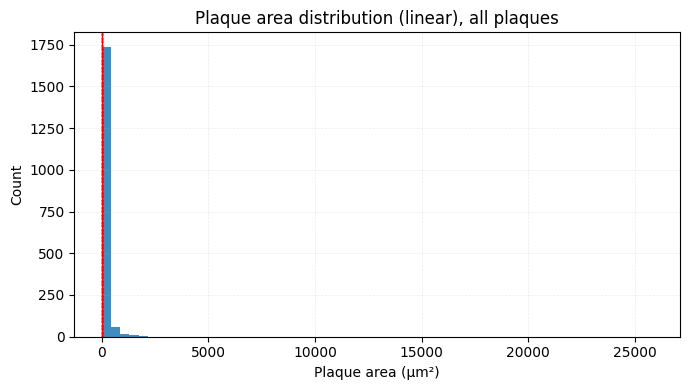

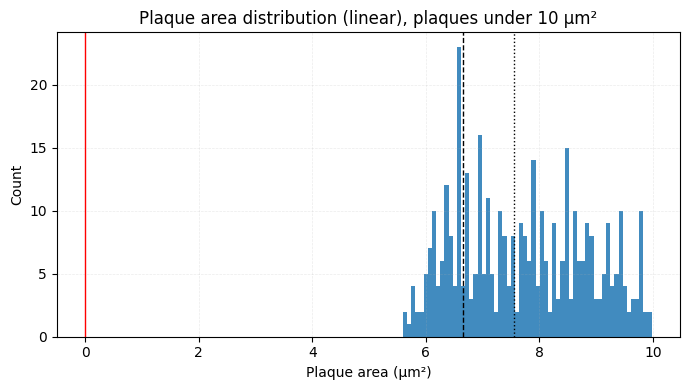

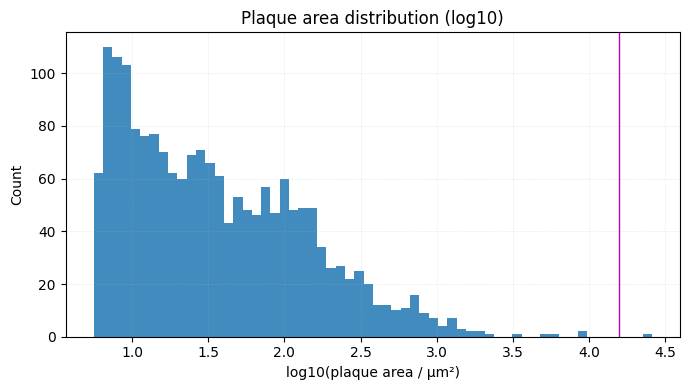

In [ ]:
# 7. Plot plaque area distribution to validate suggested cutoffs
areas = plaques_poly["area"].to_numpy()

p5, p10 = np.percentile(areas, [5, 10]) if len(areas) > 0 else (0.0, 0.0)
q1, q3 = np.percentile(areas, [25, 75]) if len(areas) > 0 else (0.0, 0.0)
iqr = q3 - q1
iqr_low = max(0.0, q1 - 1.5 * iqr)

la = np.log10(areas[areas > 0]) if (areas > 0).any() else np.array([])
knee = 0.0
if la.size > 1:
    sl = np.sort(la)
    gap_idx = int(np.argmax(np.diff(sl)))
    knee = 10 ** ((sl[gap_idx] + sl[min(gap_idx + 1, len(sl) - 1)]) / 2)

logger.info(
    {
        "n_plaques": int(len(areas)),
        "p5": float(p5),
        "p10": float(p10),
        "IQR_low": float(iqr_low),
        "knee_log10_gap": float(knee),
    }
)
# Linear area
_ = hist1d(
    areas,
    bins=60,
    thresholds=[
        (p5, "k", "--"),
        (p10, "k", ":"),
        (iqr_low, "r", "-"),
    ],
    xlabel="Plaque area (µm²)",
    ylabel="Count",
    title="Plaque area distribution (linear), all plaques",
    xlim=None,
    ylim=None,
)
areas_filtered = areas[areas < 10]
# Linear area
_ = hist1d(
    areas_filtered,
    bins=60,
    thresholds=[
        (p5, "k", "--"),
        (p10, "k", ":"),
        (iqr_low, "r", "-"),
    ],
    xlabel="Plaque area (µm²)",
    ylabel="Count",
    title="Plaque area distribution (linear), plaques under 10 µm²",
    xlim=None,
    ylim=None,
)

# Log10 area
la = np.log10(areas[areas > 0])
knee_log10 = np.log10(knee) if knee > 0 else None
thr = [(knee_log10, "m", "-")] if knee_log10 is not None else None

_ = hist1d(
    la,
    bins=60,
    thresholds=thr,
    xlabel="log10(plaque area / µm²)",
    ylabel="Count",
    title="Plaque area distribution (log10)",
    xlim=None,
    ylim=None,
)

In [ ]:
# 8. Filter out small plaques
AREA_CUTOFF = p5
plaques_poly["removed_small"] = plaques_poly["area"] < AREA_CUTOFF
plaques_poly = plaques_poly[~plaques_poly["removed_small"]].copy()
logger.info(f"kept after area cutoff: {len(plaques_poly):,} out of {len(plaques_poly):,}")

kept after area cutoff: 1,736 out of 1,736


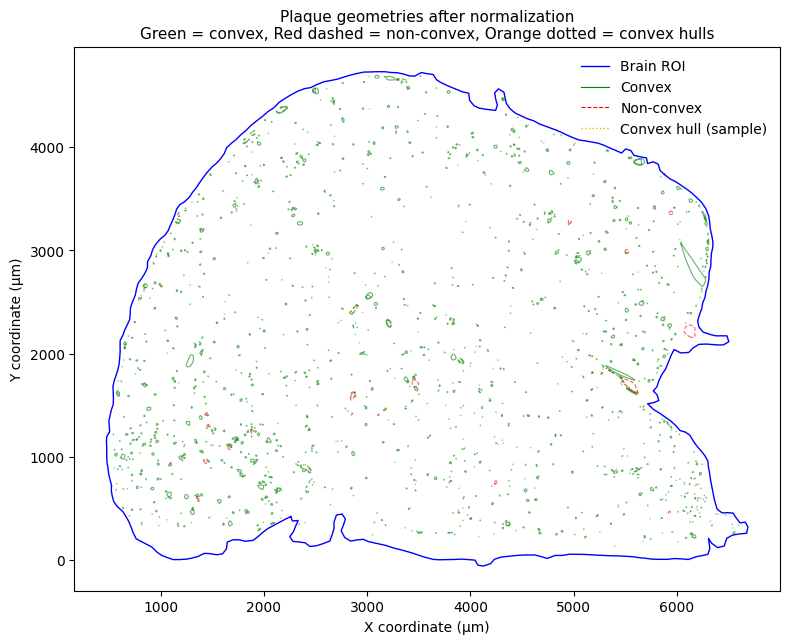

In [ ]:
ax = plot_plaques(
    plaques_poly,
    brain_geom=brain_geom if "brain_geom" in globals() else None,
    sample_hulls=20,
    seed=42,
    figsize=(8, 8),
)

In [ ]:
logger.info(
    {
        "total": len(plaques_poly),
        "convex": plaques_poly["is_convex"].sum(),
        "non_convex": (~plaques_poly["is_convex"]).sum(),
        "holes_present": plaques_poly["has_holes"].sum(),
        "mean_area": plaques_poly["area"].mean(),
        "in_brain": plaques_poly["in_brain"].mean(),
    }
)

{'total': 1736, 'convex': 1711, 'non_convex': 25, 'holes_present': 1, 'mean_area': 133.9314068292565, 'in_brain': 1.0}


Computing distances: 100%|█████████████████████████████████| 46069/46069 [00:02<00:00, 19907.98it/s]


{'cells': 46069, 'plaques_used': 1736}
{'min': 0.0, 'median': 60.57947640975828, 'mean': 67.49667454682952, 'max': 452.7904115322793, 'n': 46069, 'n_nan': 0}


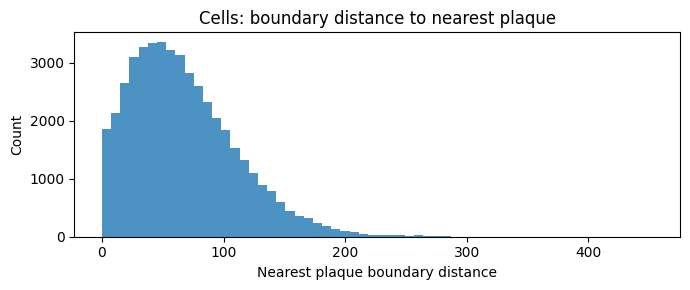

{'bin_counts': {'intermediate': 26697, 'distal': 9718, 'proximal': 9654}}


In [ ]:
cells_with_distances = compute_cell_to_plaque_distances(filtered_combined_df, plaques_poly)
df, ax = analyze_plaque_distance(
    cells_with_distances,
    column="nearest_plaque_dist",
    prox_thresh=30.0,
    distal_thresh=100.0,
    logger=logger,
    inplace=True,
)

In [ ]:
combined_df_normalized = combined_df_normalized.merge(
    cells_with_distances[
        [
            "cell_id",
            "nearest_plaque_dist",
            "nearest_plaque_center_dist",
            "inside_any_plaque",
            "nearest_plaque_id",
            "nearest_plaque_area",
        ]
    ],
    on="cell_id",
    how="left",
)
combined_df_normalized = combined_df_normalized.dropna(subset=["nearest_plaque_dist"])
combined_df_normalized = combined_df_normalized.rename(
    columns={"nearest_plaque_dist": "distance_to_plaque"}
)

# Preliminary Analysis on Preprocessed Data

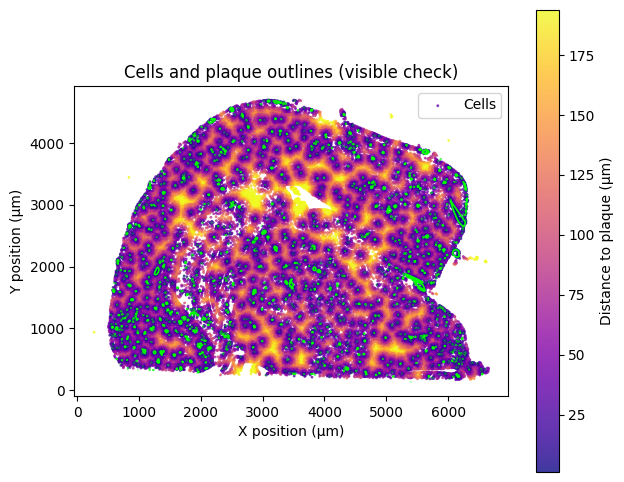

In [ ]:
# Compute and visualize per-cell distances
cells_with_distances = cells_with_distances.rename(
    columns={"nearest_plaque_dist": "distance_to_plaque"}
)
import geopandas as gpd

plaques_poly_gdf = gpd.GeoDataFrame({"geometry": plaques_poly["geometry"]})
plot_cell_to_plaque_map_visible(cells_with_distances, plaques_poly_gdf)

Assigning 6 quantile bins by distance_to_plaque
Computing mean expression per bin


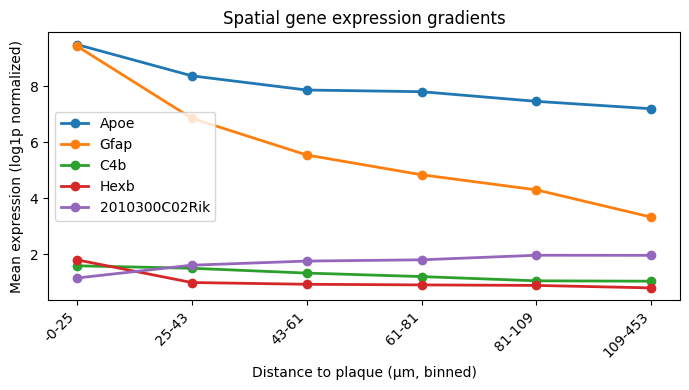

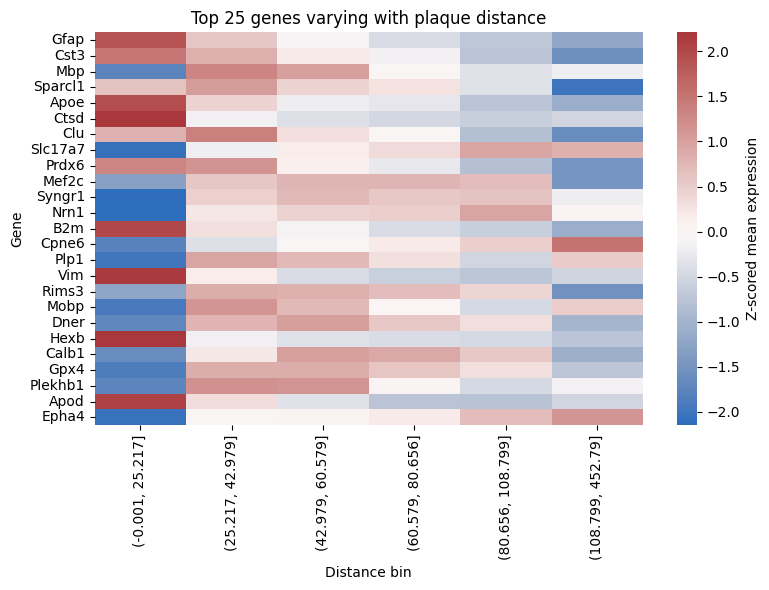

In [ ]:
combined_binned = assign_distance_bins(cells_with_distances, n_bins=6)
mean_expr = mean_expression_by_bin(combined_binned, gene_cols)
# Plot trends for known PIG genes
# TODO: Add Error bars
# TODO: Explore the 12 other PIGs
# TODO: 2010300C02Rik seems suspicious - is it a gene?
# TODO: Make bin boundaries decimal
plot_gene_trends(mean_expr, ["Apoe", "Gfap", "C4b", "Hexb", "2010300C02Rik"])
# Visualize top genes with spatial gradients
plot_mean_heatmap(mean_expr, top_n=25)

Computed spatial trends for 347 genes (FDR-corrected).


,gene,spearman_r,spearman_p,slope,fdr_pval
251,Ppp1r1b,0.092329,9.206458e-88,0.001075,9.983253e-87
0,2010300C02Rik,0.088597,6.184625e-81,0.001452,5.961291e-80
191,Meis2,0.085742,6.655236e-76,0.001218,6.077281e-75
75,Cpne6,0.085336,3.352788e-75,0.001678,2.983122e-74
187,Mdga1,0.082797,6.884410e-71,0.000556,5.695718e-70
304,Spag16,0.081647,5.618555e-69,0.000585,4.534043e-68
224,Orai2,0.076317,1.791441e-60,0.000712,1.130236e-59
280,Sema3e,0.075792,1.147221e-59,0.000779,7.108675e-59
286,Sipa1l3,0.074735,4.643610e-58,0.000971,2.826899e-57
312,Strip2,0.070969,1.609970e-52,0.001010,9.158355e-52


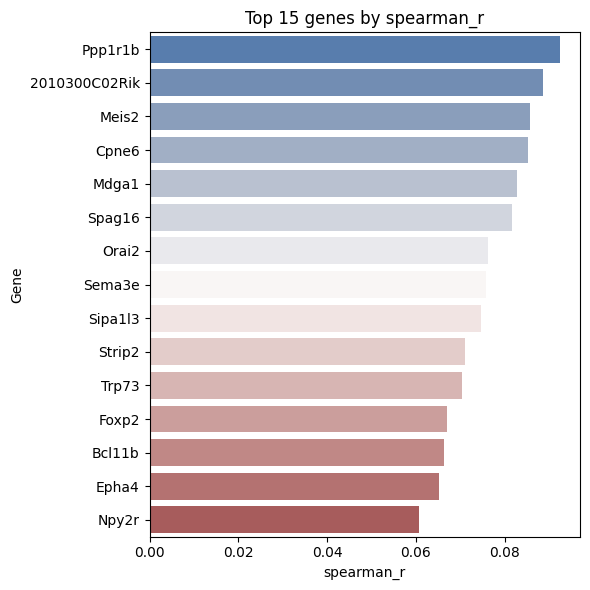

In [ ]:
stats_df = compute_gene_spatial_stats(combined_df_normalized, gene_cols)
# filter for significant positive correlations
sig_pos = stats_df.query("fdr_pval < 0.05 and spearman_r > 0").head(15)
display(sig_pos)
# visualize only significant ones
plot_top_spatial_genes(sig_pos, top_n=15, metric="spearman_r")

,gene,spearman_r,spearman_p,slope,fdr_pval,abs_spearman_r
108,Fgd5,-0.009741,0.036552,-0.000045,0.044661,0.009741
329,Tnf,-0.009818,0.035096,-0.000007,0.043033,0.009818
270,Rorb,-0.010302,0.027021,-0.000444,0.033607,0.010302
220,Olfml3,-0.011119,0.017008,-0.000027,0.021618,0.011119
55,Cdh4,-0.011295,0.015339,-0.000244,0.019569,0.011295
124,Gfra2,-0.011321,0.015101,-0.000278,0.019337,0.011321
258,Pthlh,-0.011321,0.015100,-0.000031,0.019337,0.011321
330,Tox,-0.012065,0.009606,-0.000261,0.012532,0.012065
189,Mef2c,-0.012813,0.005955,-0.000741,0.007918,0.012813
274,Rxfp1,-0.013172,0.004695,-0.000091,0.006266,0.013172


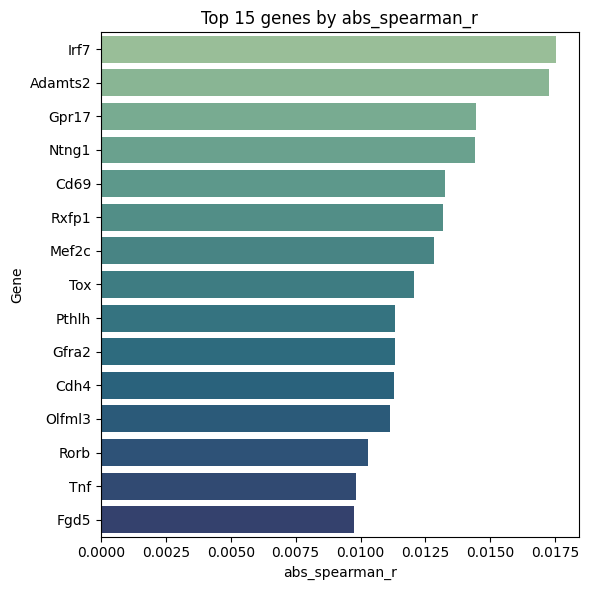

In [ ]:
# filter for significant negative correlations
sig_neg = stats_df.query("fdr_pval < 0.05 and spearman_r < 0").head(15)
sig_neg["abs_spearman_r"] = sig_neg["spearman_r"].abs()
display(sig_neg)
plot_top_spatial_genes(sig_neg, top_n=15, metric="abs_spearman_r")

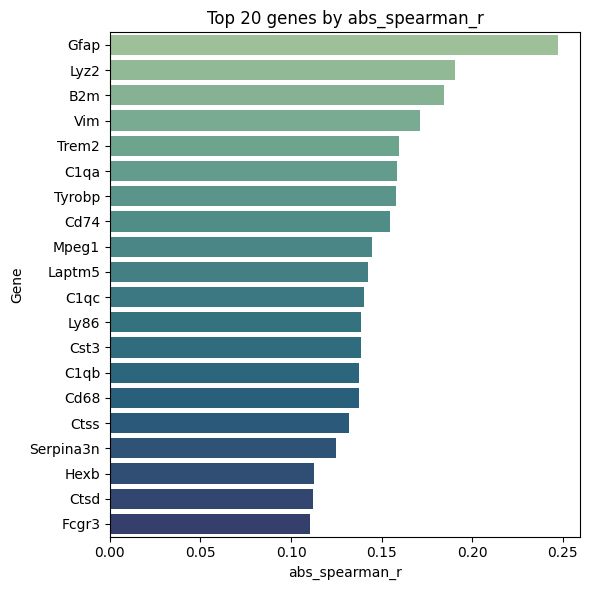

In [ ]:
plot_top_spatial_genes(
    stats_df.query("gene != 'total_counts'").assign(abs_spearman_r=stats_df["spearman_r"].abs()),
    metric="abs_spearman_r",
)

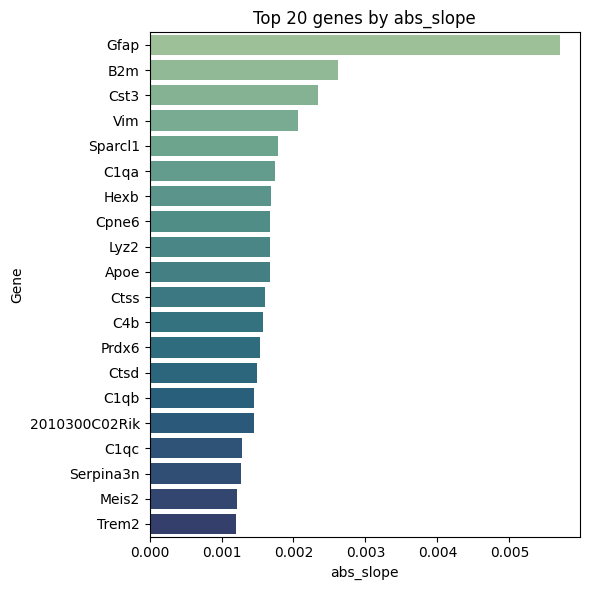

In [ ]:
plot_top_spatial_genes(
    stats_df.query("gene != 'total_counts'").assign(abs_slope=stats_df["slope"].abs()),
    metric="abs_slope",
)

# Exploration on gene expression data

In [ ]:
# TODO: is it a good idea to normalize before the analysis above?
# 1. Compute per-gene summary statistics on filtered cells

g = filtered_combined_df[gene_cols]
summary = summarize_genes(filtered_combined_df[gene_cols])

logger.info(f"Genes summarized: {len(summary):,}")
display(summary.head(10))

Genes summarized: 347


,mean,std,median,mad,skew,kurtosis,nonzero_frac
gene,,,,,,,
2010300C02Rik,1.712800,2.988822,0.0,0.0,2.979077,12.765290,0.475526
Abca7,0.245197,0.579600,0.0,0.0,2.901828,10.351441,0.187306
Acsbg1,0.853068,1.346794,0.0,0.0,2.545717,9.786340,0.442163
Acta2,0.147453,0.810502,0.0,0.0,12.843190,236.358910,0.084547
Acvrl1,0.103931,0.442446,0.0,0.0,5.843195,44.579918,0.070199
Adamts2,0.145629,0.513085,0.0,0.0,5.176413,39.983467,0.101348
Adamtsl1,0.095292,0.363096,0.0,0.0,5.048777,38.417608,0.077753
Adgrl4,0.179991,0.682918,0.0,0.0,5.372806,37.072354,0.097007
Aldh1a2,0.090256,0.650977,0.0,0.0,11.839703,198.145108,0.035794


In [ ]:
# 2. Verify that PIGs are present in the expression data and perform z-normalization for exploration"

pigs_z, info = compute_pigs_zscores(filtered_combined_df, gene_cols)
logger.info(f"PIGs present: {len(info['present'])} | Missing: {info['missing']}")
logger.info(f"Z-scored PIG matrix shape: {pigs_z.shape}")
display(pigs_z.head())

PIGs present: 16 | Missing: []


Z-scored PIG matrix shape: (46069, 16)


,Hexb,Cst3,Cd63,C4b,Ctsd,B2m,H2-K1,Apoe,Gfap,Nrep,Serpina3n,Cd74,Cxcl10,Vim,S100a6,Ifit3
0,-0.513914,0.830873,-0.219339,0.810967,3.330818,0.124532,0.308896,-0.290304,0.284959,4.159464,-0.415827,-0.228775,-0.072529,-0.443656,-0.46100,0.563622
1,-0.028273,0.515173,0.331988,-0.612396,-0.132512,1.123930,0.308896,0.139351,0.409749,2.994983,1.658609,-0.228775,-0.072529,0.062844,-0.46100,-0.363023
2,-0.028273,0.278398,0.331988,-0.137942,-0.421123,-0.375168,1.243089,0.998659,-0.089411,-0.498460,0.967130,-0.228775,-0.072529,-0.443656,-0.46100,0.563622
3,1.428651,1.225497,1.985966,1.285421,5.351094,3.622427,-0.625296,0.998659,0.534539,5.906186,0.275652,0.727356,-0.072529,0.062844,-0.46100,0.563622
4,-0.028273,0.909798,-0.770665,-0.612396,0.444710,-0.874867,0.308896,-0.003867,2.531180,2.994983,-0.415827,-0.228775,-0.072529,1.075843,1.74438,-0.363023


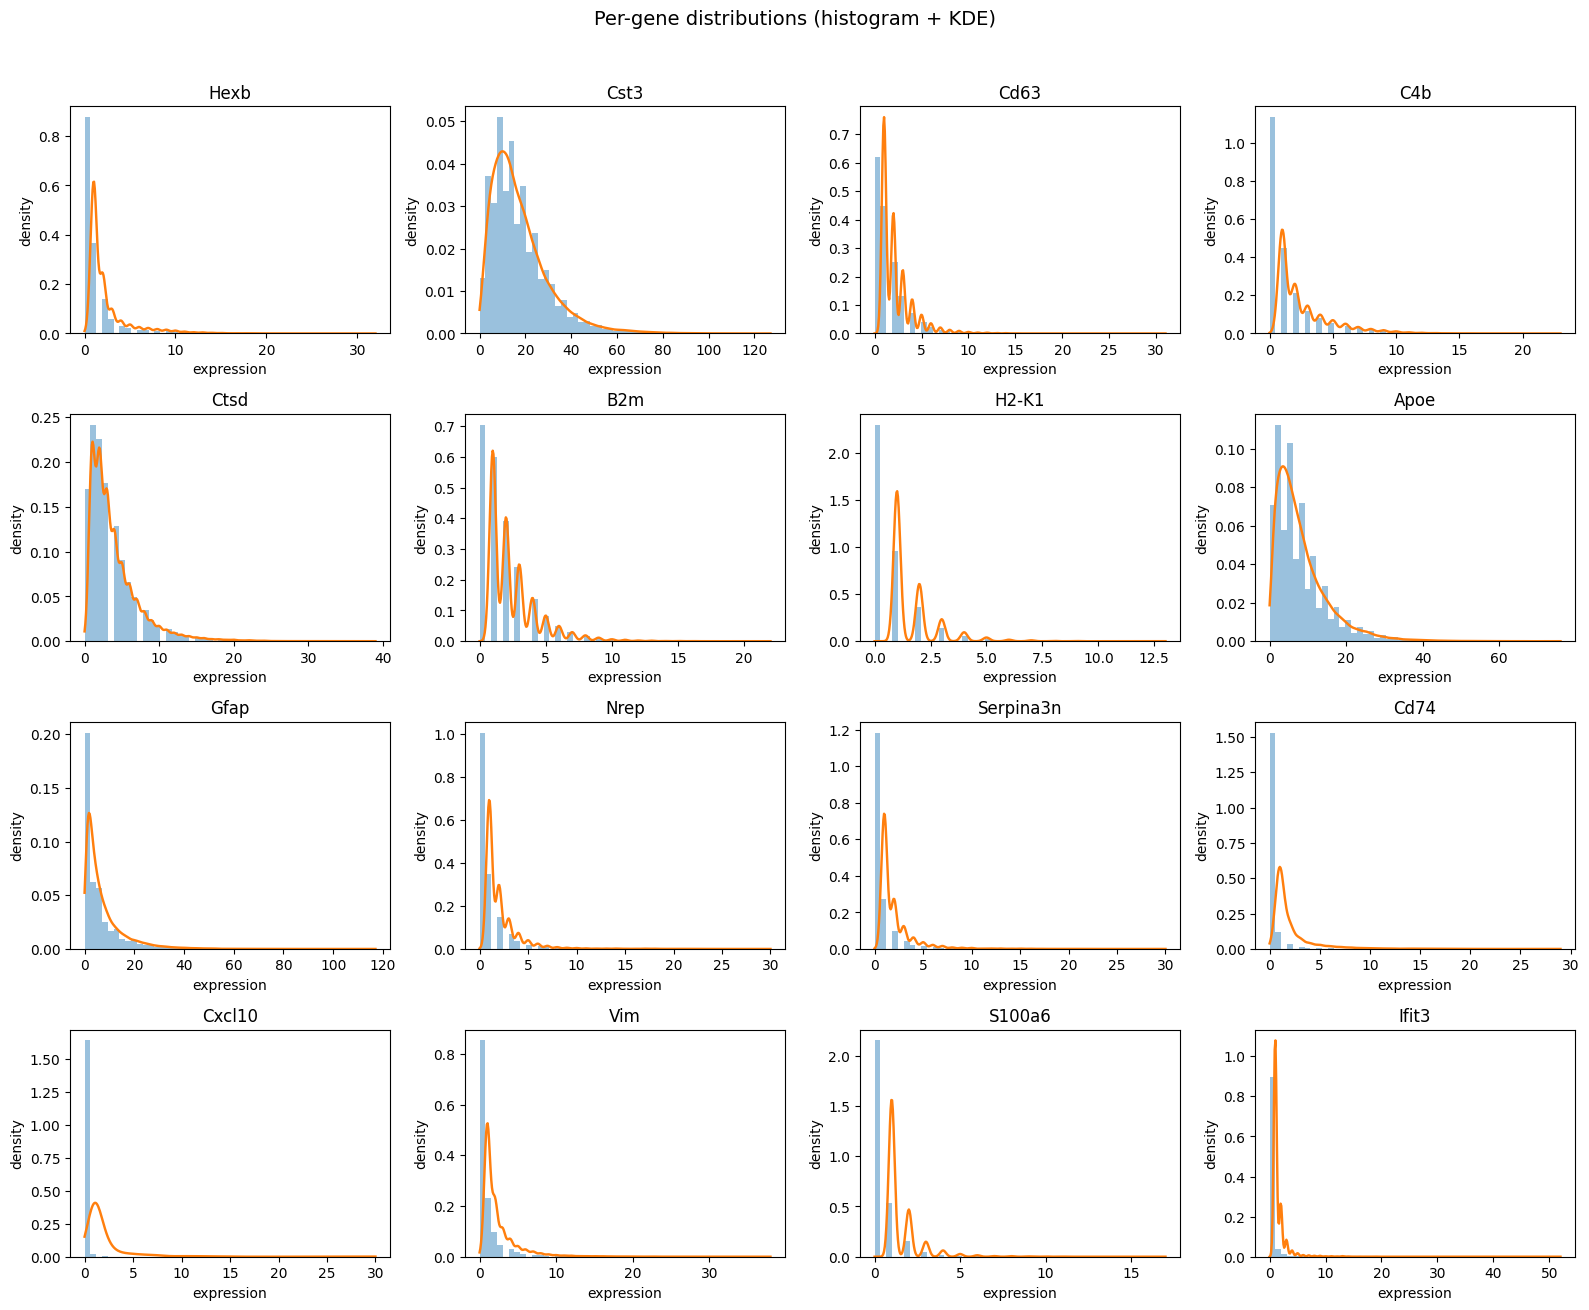

In [ ]:
# 3. Plot the histogram + KDE for PIGs
_ = plot_gene_distributions(filtered_combined_df, genes=info["present"])

In [ ]:
# 4. For each gene, compute its unusualness based on zero-inflation, dispersion, and shape
S, Z = compute_weird_gene_scores(
    filtered_combined_df[gene_cols], clip_z=3.0, ddof_std=0, PIGs=info["present"]
)
logger.info(f"Genes evaluated: {len(S):,}")
logger.info("\nTop 20 by WEIRD SCORE")
display(S.head(20))
logger.info("\nTop 10 by ZERO FRAC")
display(
    S.sort_values("zero_frac", ascending=False).head(10)[
        ["isPIG", "zero_frac", "mean", "cv", "skew", "kurtosis"]
    ]
)
logger.info("\nTop 10 by |SKEW|")
display(
    S.reindex(S["skew"].abs().sort_values(ascending=False).head(10).index)[
        ["isPIG", "skew", "kurtosis", "zero_frac", "cv"]
    ]
)
logger.info("\nTop 10 by KURTOSIS")
display(
    S.sort_values("kurtosis", ascending=False).head(10)[
        ["isPIG", "kurtosis", "skew", "zero_frac", "cv"]
    ]
)

Genes evaluated: 347

Top 20 by WEIRD SCORE


,zero_frac,nonzero_frac,mean,std,cv,skew,kurtosis,q10,q90,tail_ratio,isPIG,weird_score
Tnf,0.997764,0.002236,0.002431,0.063494,26.117086,70.948719,8905.796562,0.0,0.0,1.0,False,9.350969
Chat,0.994790,0.005210,0.006512,0.125539,19.278149,65.674141,7640.572432,0.0,0.0,1.0,False,9.336374
Cxcl10,0.985022,0.014978,0.029977,0.413306,13.787550,35.258972,1874.985780,0.0,0.0,1.0,True,8.992216
Slc6a3,0.997439,0.002561,0.003147,0.070741,22.475685,32.671627,1470.905463,0.0,0.0,1.0,False,8.428571
Lcn2,0.997829,0.002171,0.002409,0.054876,22.775641,28.635225,1129.043340,0.0,0.0,1.0,False,7.902077
Th,0.983633,0.016367,0.031952,0.390608,12.224816,27.675546,1071.163030,0.0,0.0,1.0,False,7.387061
Cort,0.975276,0.024724,0.037531,0.367565,9.793727,26.447535,1098.818190,0.0,0.0,1.0,False,6.620797
Cd69,0.997677,0.002323,0.002323,0.048137,20.725622,20.678046,425.600050,0.0,0.0,1.0,False,6.029370
Nme8,0.995854,0.004146,0.004363,0.069437,15.914945,17.511958,357.702672,0.0,0.0,1.0,False,5.429225
Pln,0.986781,0.013219,0.025006,0.280905,11.233515,17.554003,400.403412,0.0,0.0,1.0,False,4.788118



Top 10 by ZERO FRAC


,isPIG,zero_frac,mean,cv,skew,kurtosis
Lcn2,False,0.997829,0.002409,22.775641,28.635225,1129.043340
Tnf,False,0.997764,0.002431,26.117086,70.948719,8905.796562
Cd69,False,0.997677,0.002323,20.725622,20.678046,425.600050
Slc6a3,False,0.997439,0.003147,22.475685,32.671627,1470.905463
Nme8,False,0.995854,0.004363,15.914945,17.511958,357.702672
Chat,False,0.994790,0.006512,19.278149,65.674141,7640.572432
Dkk2,False,0.993423,0.007098,12.772980,14.532576,253.630245
Ptx3,False,0.990992,0.009594,10.985378,13.705634,281.177731
Tgm1,False,0.989451,0.012633,10.869340,15.921167,379.441725
Pln,False,0.986781,0.025006,11.233515,17.554003,400.403412



Top 10 by |SKEW|


,isPIG,skew,kurtosis,zero_frac,cv
Tnf,False,70.948719,8905.796562,0.997764,26.117086
Chat,False,65.674141,7640.572432,0.994790,19.278149
Cxcl10,True,35.258972,1874.985780,0.985022,13.787550
Slc6a3,False,32.671627,1470.905463,0.997439,22.475685
Lcn2,False,28.635225,1129.043340,0.997829,22.775641
Th,False,27.675546,1071.163030,0.983633,12.224816
Cort,False,26.447535,1098.818190,0.975276,9.793727
Cd69,False,20.678046,425.600050,0.997677,20.725622
Ebf3,False,18.473291,594.690689,0.976492,8.760797
Nts,False,18.035900,433.834434,0.964553,9.212135



Top 10 by KURTOSIS


,isPIG,kurtosis,skew,zero_frac,cv
Tnf,False,8905.796562,70.948719,0.997764,26.117086
Chat,False,7640.572432,65.674141,0.994790,19.278149
Cxcl10,True,1874.985780,35.258972,0.985022,13.787550
Slc6a3,False,1470.905463,32.671627,0.997439,22.475685
Lcn2,False,1129.043340,28.635225,0.997829,22.775641
Cort,False,1098.818190,26.447535,0.975276,9.793727
Th,False,1071.163030,27.675546,0.983633,12.224816
Ebf3,False,594.690689,18.473291,0.976492,8.760797
Nts,False,433.834434,18.035900,0.964553,9.212135
Chodl,False,427.723198,17.209909,0.979943,9.380404


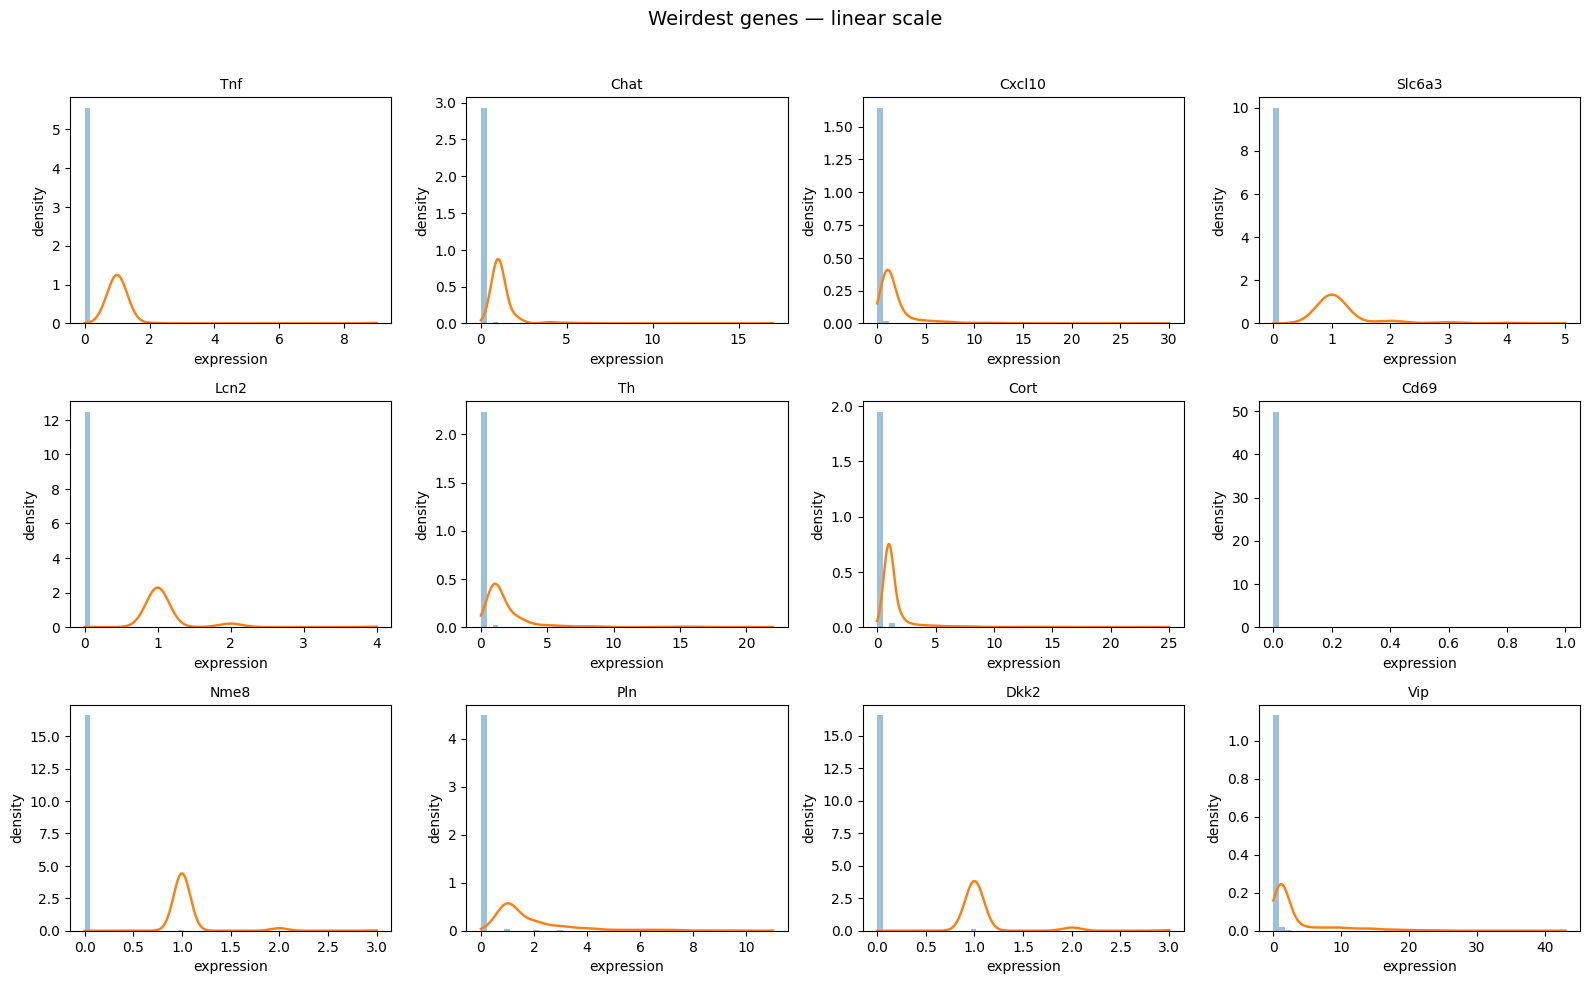

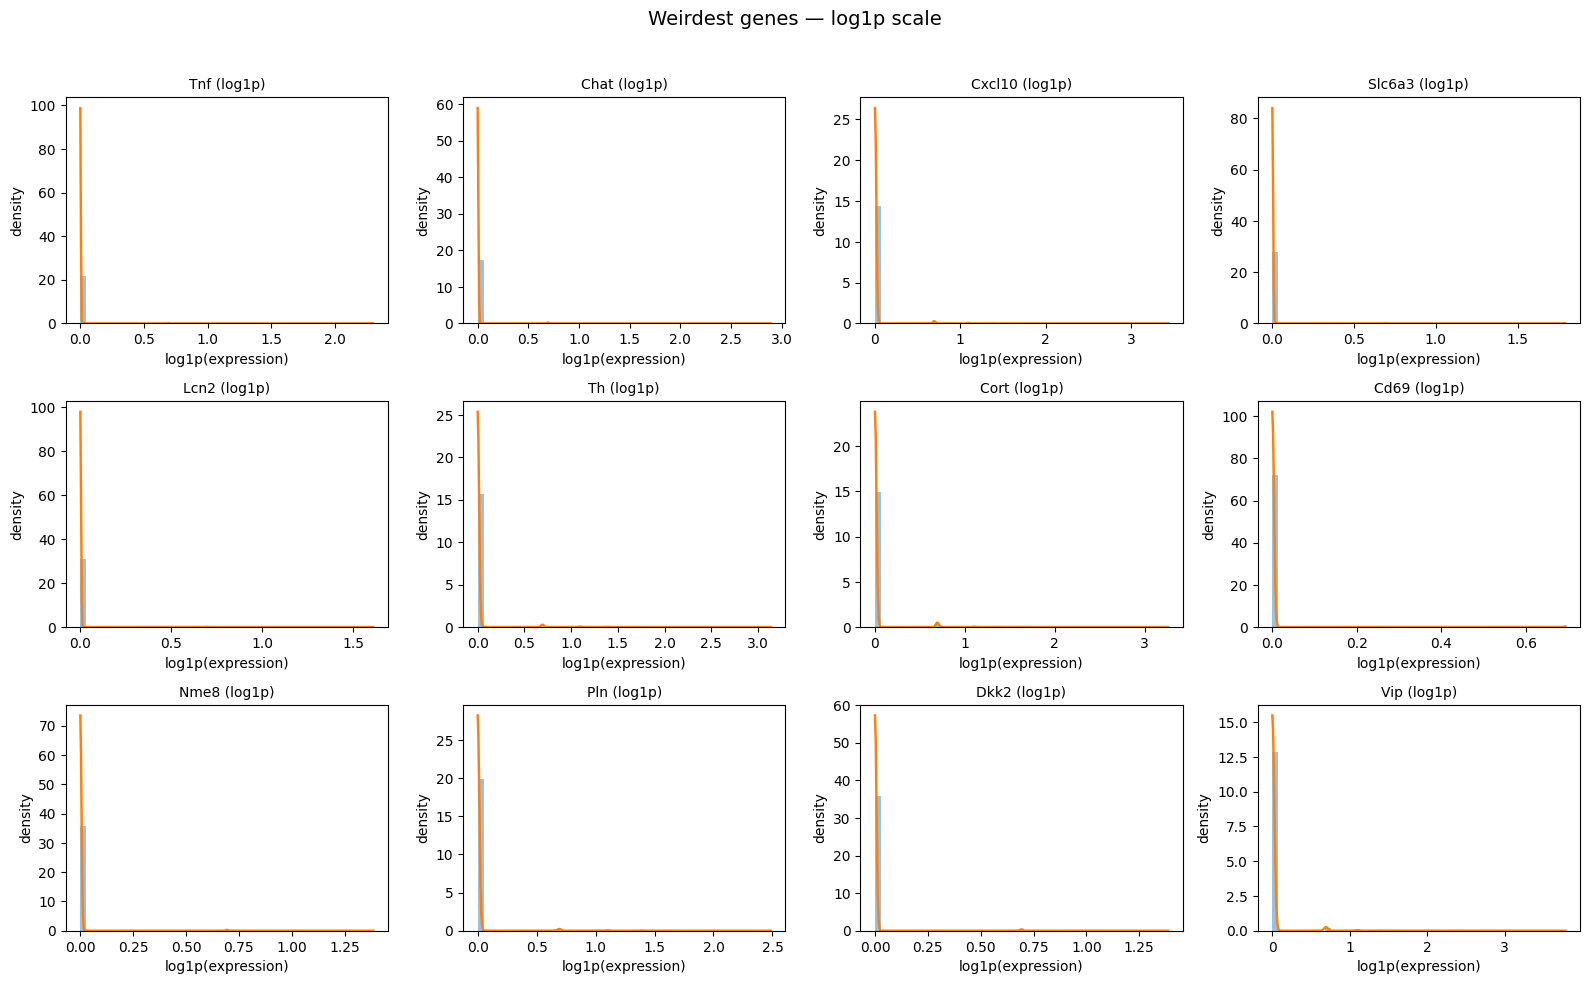

(<Figure size 1600x960 with 12 Axes>, <Figure size 1600x960 with 12 Axes>)

In [ ]:
# 5. Plot the historgram and KDE for weirdest genes (linear and log1p)

genes_to_plot = S.head(12).index.tolist()

plot_weird_gene_panels(
    filtered_combined_df,
    genes_to_plot,
    bins=50,
    cols=4,
    show=True,
)

In [ ]:
# 6. Save cleaned cells, gene summary, and PIG z-matrix

filtered_combined_df.to_parquet(f"{PATH_TO_DATA_FOLDER}/cells_cleaned.parquet")
summary.to_parquet(f"{PATH_TO_DATA_FOLDER}/gene_summary.parquet")
pigs_z.to_parquet(f"{PATH_TO_DATA_FOLDER}/pigs_z.parquet")
logger.info("Written: cells_cleaned.parquet, gene_summary.parquet, pigs_z.parquet")

Written: cells_cleaned.parquet, gene_summary.parquet, pigs_z.parquet


Research Question 1 — Plaque-Induced Gene (PIG) Expression Gradients

=== QC: Combined dataset after merging spatial info ===
Shape: (56956, 363)

Present distance columns: ['distance_to_plaque', 'nearest_plaque_dist', 'nearest_plaque_center_dist', 'nearest_plaque_id', 'nearest_plaque_area', 'inside_any_plaque']

Distance difference stats (should be close to 0):
count    5.695600e+04
mean     1.942213e+00
std      1.144501e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.065814e-13
max      4.448382e+02
dtype: float64

Missing values per distance column:


distance_to_plaque            0
nearest_plaque_dist           0
nearest_plaque_center_dist    0
nearest_plaque_id             0
nearest_plaque_area           0
inside_any_plaque             0
dtype: int64


Nearest plaque distance summary (µm):
count    56956.000000
mean        68.557212
std         44.787599
min          0.000000
25%         34.673606
50%         61.516188
75%         94.578283
max        457.648172
Name: nearest_plaque_dist, dtype: float64

Unique plaque IDs linked: 1634


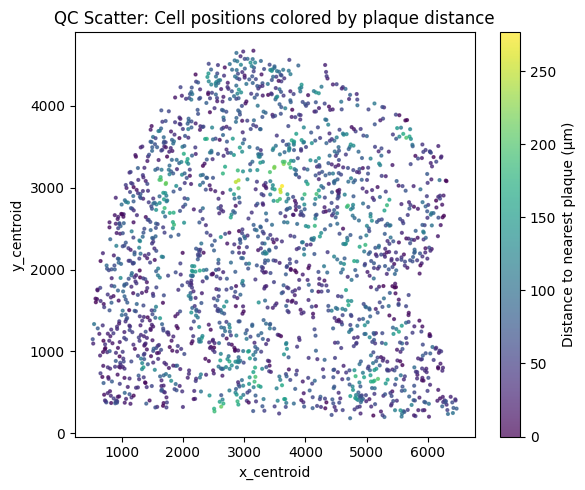

In [ ]:
import numpy as np
import pandas as pd

logger.info("=== QC: Combined dataset after merging spatial info ===")
logger.info("Shape:", combined_df_normalized.shape)

# Check key distance columns
key_cols = [
    "distance_to_plaque",
    "nearest_plaque_dist",
    "nearest_plaque_center_dist",
    "nearest_plaque_id",
    "nearest_plaque_area",
    "inside_any_plaque",
]
present = [c for c in key_cols if c in combined_df_normalized.columns]
missing = [c for c in key_cols if c not in combined_df_normalized.columns]
logger.info("\nPresent distance columns:", present)
if missing:
    logger.info("Missing distance columns:", missing)

# Compare consistency of distance columns (they should be almost identical)
if (
    "distance_to_plaque" in combined_df_normalized.columns
    and "nearest_plaque_dist" in combined_df_normalized.columns
):
    diff = (
        combined_df_normalized["distance_to_plaque"] - combined_df_normalized["nearest_plaque_dist"]
    ).abs()
    logger.info("\nDistance difference stats (should be close to 0):")
    logger.info(diff.describe())

# Check for missing values in distance columns
logger.info("\nMissing values per distance column:")
display(combined_df_normalized[key_cols].isna().sum())

# Check distribution of nearest plaque distances
if "nearest_plaque_dist" in combined_df_normalized.columns:
    logger.info("\nNearest plaque distance summary (µm):")
    logger.info(combined_df_normalized["nearest_plaque_dist"].describe())

# Check number of unique plaques referenced
if "nearest_plaque_id" in combined_df_normalized.columns:
    n_unique_plaques = combined_df_normalized["nearest_plaque_id"].nunique()
    logger.info(f"\nUnique plaque IDs linked: {n_unique_plaques}")

# visual sanity check (scatter of coordinates vs distance)
import matplotlib.pyplot as plt

if all(
    c in combined_df_normalized.columns for c in ["x_centroid", "y_centroid", "nearest_plaque_dist"]
):
    sample = combined_df_normalized.sample(2000, random_state=0)
    plt.figure(figsize=(6, 5))
    plt.scatter(
        sample["x_centroid"],
        sample["y_centroid"],
        c=sample["nearest_plaque_dist"],
        cmap="viridis",
        s=4,
        alpha=0.7,
    )
    plt.colorbar(label="Distance to nearest plaque (µm)")
    plt.title("QC Scatter: Cell positions colored by plaque distance")
    plt.xlabel("x_centroid")
    plt.ylabel("y_centroid")
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd

PIG_GENES = [
    "Hexb",
    "Cst3",
    "CD63",
    "C4b",
    "Ctsd",
    "B2m",
    "H2-K1",
    "Apoe",
    "Gfap",
    "Nrep",
    "Serpina3n",
    "Cd74",
    "Cxcl10",
    "Vim",
    "S100a6",
    "Ifit3",
]

logger.info("=== Xenium TgCRND8 17.9-month dataset check ===")
logger.info("DataFrame name: combined_df_normalized")
logger.info("Shape:", combined_df_normalized.shape)

# Check core columns
core_cols = ["cell_id", "distance_to_plaque", "x_centroid", "y_centroid"]
logger.info("\nChecking required columns:")
for col in core_cols:
    logger.info(f" - {col}: {'✅' if col in combined_df_normalized.columns else '❌ MISSING'}")

# Check which PIG genes are present
present_genes = [g for g in PIG_GENES if g in combined_df_normalized.columns]
missing_genes = [g for g in PIG_GENES if g not in combined_df_normalized.columns]

logger.info("\nPIG genes present:", present_genes)
logger.info("Missing genes:", missing_genes)

# Quick numeric summary for distance
if "distance_to_plaque" in combined_df_normalized.columns:
    logger.info("\nDistance-to-plaque summary:")
    logger.info(combined_df_normalized["distance_to_plaque"].describe())

# Quick peek at the data
display(combined_df_normalized.head(3))

=== Xenium TgCRND8 17.9-month dataset check ===
DataFrame name: combined_df_2
Shape: (56956, 363)

Checking required columns:
 - cell_id: ✅
 - distance_to_plaque: ✅
 - x_centroid: ✅
 - y_centroid: ✅

PIG genes present: ['Hexb', 'Cst3', 'C4b', 'Ctsd', 'B2m', 'H2-K1', 'Apoe', 'Gfap', 'Nrep', 'Serpina3n', 'Cd74', 'Cxcl10', 'Vim', 'S100a6', 'Ifit3']
Missing genes: ['CD63']

Distance-to-plaque summary:
count    56956.000000
mean        66.614999
std         43.249479
min          0.000000
25%         33.678844
50%         59.943459
75%         92.263029
max        310.348012
Name: distance_to_plaque, dtype: float64


,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,total_counts,cell_area,nucleus_area,...,Vwc2l,Wfs1,Zfp366,Zfp536,Zfpm2,nearest_plaque_dist,nearest_plaque_center_dist,inside_any_plaque,nearest_plaque_id,nearest_plaque_area
0,aaabiggh-1,831.785336,755.803772,554,0,0,0,554,509.091563,65.386250,...,1.386294,0.000000,0.0,0.0,0.693147,35.775568,37.792455,False,18.0,11.193952
1,aaacfoel-1,821.733453,768.910446,291,0,0,0,291,275.498281,36.982969,...,1.098612,0.000000,0.0,0.0,0.693147,37.307845,39.613572,False,19.0,14.258411
2,aaaeefil-1,831.932053,780.367651,220,1,0,0,221,261.635312,15.849844,...,0.000000,0.693147,0.0,0.0,1.098612,23.175138,25.439406,False,19.0,14.258411


Step 2 – Bin cells by distance and compute average PIG expression

In [ ]:
import numpy as np
import pandas as pd

# Define the distance bins (in µm)
bins = [0, 20, 50, 100, 200, np.inf]
labels = ["0–20 µm", "20–50 µm", "50–100 µm", "100–200 µm", ">200 µm"]

combined_df_normalized["distance_bin"] = pd.cut(
    combined_df_normalized["nearest_plaque_dist"], bins=bins, labels=labels, include_lowest=True
)

# Define which PIG genes are available
PIG_GENES = [
    "Hexb",
    "Cst3",
    "C4b",
    "Ctsd",
    "B2m",
    "H2-K1",
    "Apoe",
    "Gfap",
    "Nrep",
    "Serpina3n",
    "Cd74",
    "Cxcl10",
    "Vim",
    "S100a6",
    "Ifit3",  # CD63 missing in dataset
]
pig_cols = [g for g in PIG_GENES if g in combined_df_normalized.columns]

# Compute mean and standard error for each distance bin
mean_expr = combined_df_normalized.groupby("distance_bin")[pig_cols].mean().reset_index()
sem_expr = combined_df_normalized.groupby("distance_bin")[pig_cols].sem().reset_index()

# Merge for clarity
summary_df = mean_expr.melt(id_vars="distance_bin", var_name="gene", value_name="mean_expr")
sem_melted = sem_expr.melt(id_vars="distance_bin", var_name="gene", value_name="sem_expr")
summary_df = summary_df.merge(sem_melted, on=["distance_bin", "gene"], how="left")

logger.info("Mean ± SEM of PIG expression by distance bin:")
display(summary_df.head(15))

# Also check how many cells fall into each bin
logger.info("\nCell counts per distance bin:")
display(combined_df_normalized["distance_bin"].value_counts().sort_index())

Mean ± SEM of PIG expression by distance bin:


,distance_bin,gene,mean_expr,sem_expr
0,0–20 µm,Hexb,0.687720,0.009358
1,20–50 µm,Hexb,0.418897,0.004733
2,50–100 µm,Hexb,0.381412,0.003822
3,100–200 µm,Hexb,0.351220,0.004981
4,>200 µm,Hexb,0.350095,0.020697
5,0–20 µm,Cst3,2.641352,0.010180
6,20–50 µm,Cst3,2.613018,0.006486
7,50–100 µm,Cst3,2.512104,0.005411
8,100–200 µm,Cst3,2.364412,0.007682
9,>200 µm,Cst3,2.017389,0.034777



Cell counts per distance bin:


distance_bin
0–20 µm        7016
20–50 µm      15358
50–100 µm     22086
100–200 µm    11934
>200 µm         562
Name: count, dtype: int64

Step 3 — Visualize Expression vs Distance

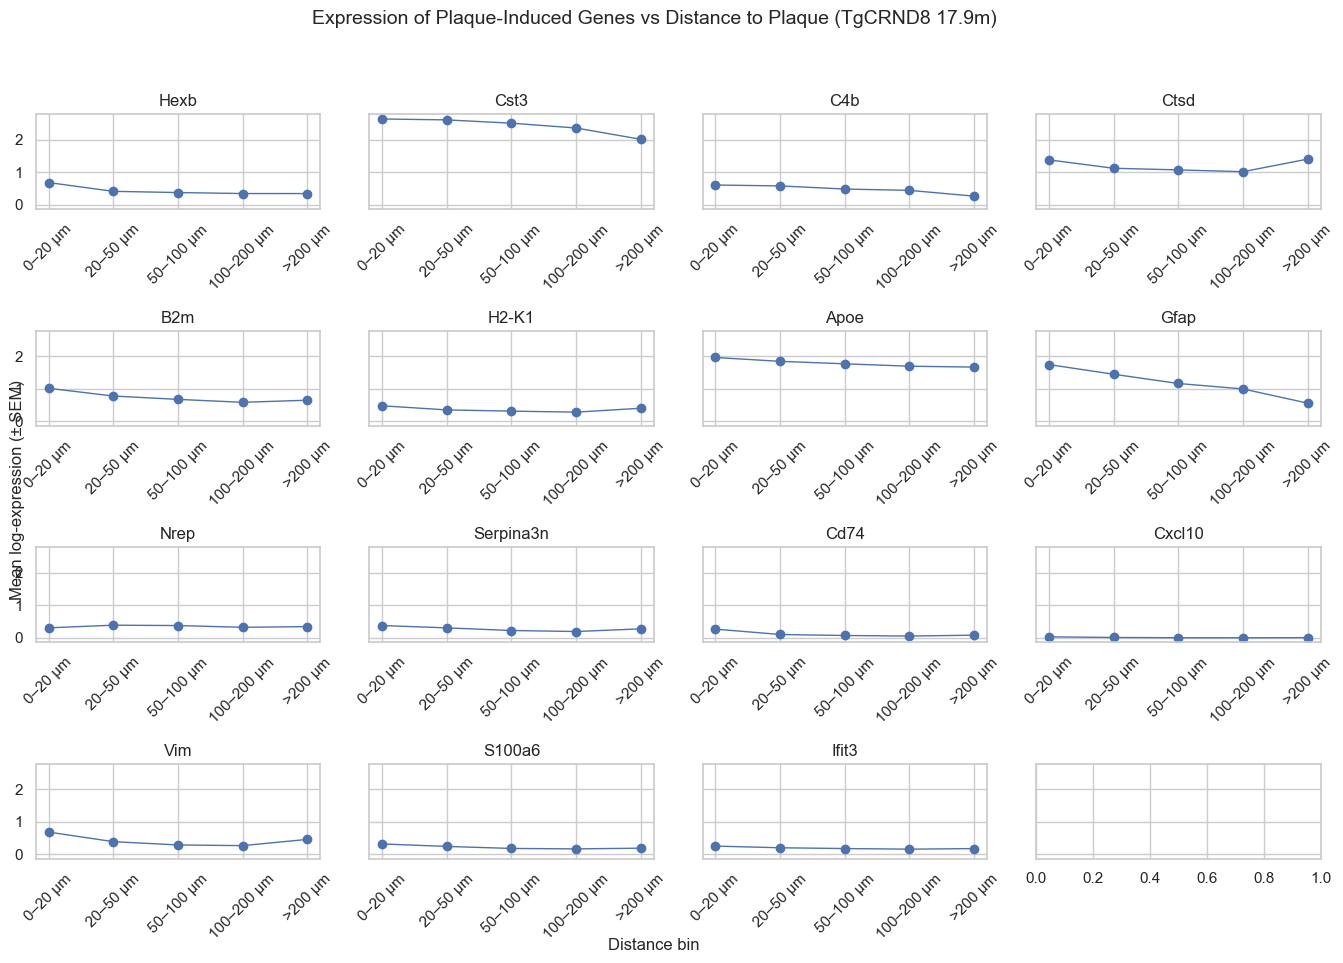

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

genes_to_plot = [g for g in PIG_GENES if g in summary_df["gene"].unique()]

n_genes = len(genes_to_plot)
n_cols = 4
n_rows = int(np.ceil(n_genes / n_cols))

sns.set(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2.5), sharey=True)
axes = axes.flatten()

for i, g in enumerate(genes_to_plot):
    df = summary_df[summary_df["gene"] == g]
    ax = axes[i]
    ax.errorbar(
        df["distance_bin"],
        df["mean_expr"],
        yerr=df["sem_expr"],
        marker="o",
        capsize=3,
        linewidth=1,
    )
    ax.set_title(g)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)

# Global labels
fig.suptitle(
    "Expression of Plaque-Induced Genes vs Distance to Plaque (TgCRND8 17.9m)", fontsize=14
)
fig.text(0.5, 0.04, "Distance bin", ha="center", fontsize=12)
fig.text(0.04, 0.5, "Mean log-expression (± SEM)", va="center", rotation="vertical", fontsize=12)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

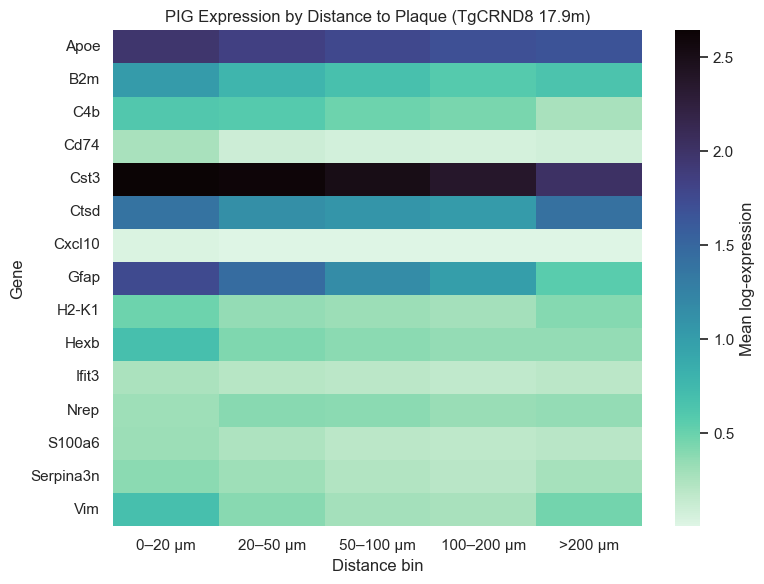

In [ ]:
plt.figure(figsize=(8, 6))
heatmap_df = summary_df.pivot(index="gene", columns="distance_bin", values="mean_expr")
sns.heatmap(heatmap_df, cmap="mako_r", cbar_kws={"label": "Mean log-expression"})
plt.title("PIG Expression by Distance to Plaque (TgCRND8 17.9m)")
plt.xlabel("Distance bin")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

proximal plaques show elevated microglial (Hexb, Ctsd, Cst3, Apoe) and astrocytic (Gfap, Serpina3n, Vim) expression that fades with distance.

Step 4a — Continuous model: per-gene linear regression

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

results = []

# Use all available PIG genes
pig_cols = [g for g in PIG_GENES if g in combined_df_normalized.columns]

for gene in pig_cols:
    df = combined_df_normalized[[gene, "nearest_plaque_dist"]].dropna()
    X = sm.add_constant(df["nearest_plaque_dist"])  # adds intercept
    y = df[gene]
    model = sm.OLS(y, X).fit()
    slope = model.params["nearest_plaque_dist"]
    pval = model.pvalues["nearest_plaque_dist"]
    results.append({"gene": gene, "slope": slope, "pval": pval})

# Convert to DataFrame
reg_df = pd.DataFrame(results)
reg_df["qval"] = multipletests(reg_df["pval"], method="fdr_bh")[1]
reg_df = reg_df.sort_values("slope")

logger.info("Continuous regression results (expression ~ distance):")
display(reg_df)

# Highlight top plaque-proximal genes (negative slope)
proximal_genes = reg_df[reg_df["slope"] < 0].sort_values("qval").head(10)
logger.info("\nTop plaque-proximal genes (negative slope, smallest q-values):")
display(proximal_genes)

Continuous regression results (expression ~ distance):


,gene,slope,pval,qval
7,Gfap,-0.005313,0.000000e+00,0.000000e+00
1,Cst3,-0.002509,5.223421e-234,1.958783e-233
4,B2m,-0.002498,0.000000e+00,0.000000e+00
12,Vim,-0.001909,3.814466e-268,1.907233e-267
6,Apoe,-0.001712,8.565298e-109,1.284795e-108
0,Hexb,-0.001610,4.513449e-178,1.128362e-177
3,Ctsd,-0.001541,2.803488e-108,3.822938e-108
2,C4b,-0.001405,3.996474e-116,7.493388e-116
9,Serpina3n,-0.001157,9.263298e-142,1.984993e-141
10,Cd74,-0.000984,1.537710e-210,4.613131e-210



Top plaque-proximal genes (negative slope, smallest q-values):


,gene,slope,pval,qval
7,Gfap,-0.005313,0.000000e+00,0.000000e+00
4,B2m,-0.002498,0.000000e+00,0.000000e+00
12,Vim,-0.001909,3.814466e-268,1.907233e-267
1,Cst3,-0.002509,5.223421e-234,1.958783e-233
10,Cd74,-0.000984,1.537710e-210,4.613131e-210
0,Hexb,-0.001610,4.513449e-178,1.128362e-177
9,Serpina3n,-0.001157,9.263298e-142,1.984993e-141
2,C4b,-0.001405,3.996474e-116,7.493388e-116
13,S100a6,-0.000868,5.654290e-116,9.423817e-116
6,Apoe,-0.001712,8.565298e-109,1.284795e-108


Each slope shows how much the log-expression changes per micron away from a plaque. Gene expression decreases as you move away from plaques — consistent with microglial/astrocytic activation. Top genes: Gfap, Cst3, Apoe, Hexb, Serpina3n, Vim are canonical plaque-induced genes
Slopes are small but consistent (−0.001 to −0.005) Because the unit is µm; a 100 µm shift corresponds to roughly 0.1–0.5 log change. Nrep, Ifit3, Cxcl10 show weak slopes so these genes are less spatially patterned.

Step 4b — Categorical model (ANOVA-style)

In [ ]:
import re

import statsmodels.formula.api as smf

anova_results = []

for gene in pig_cols:
    df = combined_df_normalized[[gene, "distance_bin"]].dropna()
    safe_gene = re.sub(r"[^0-9a-zA-Z_]", "_", gene)  # replace symbols like "-" with "_"
    df = df.rename(columns={gene: safe_gene})

    model = smf.ols(f"{safe_gene} ~ C(distance_bin)", data=df).fit()
    aov_table = sm.stats.anova_lm(model, typ=2)
    pval = aov_table["PR(>F)"].iloc[0]
    anova_results.append({"gene": gene, "anova_pval": pval})

anova_df = pd.DataFrame(anova_results)
anova_df["qval"] = multipletests(anova_df["anova_pval"], method="fdr_bh")[1]
anova_df = anova_df.sort_values("anova_pval")

logger.info("Categorical ANOVA results (expression ~ distance_bin):")
display(anova_df.head(10))

Categorical ANOVA results (expression ~ distance_bin):


,gene,anova_pval,qval
0,Hexb,0.000000e+00,0.000000e+00
4,B2m,0.000000e+00,0.000000e+00
7,Gfap,0.000000e+00,0.000000e+00
10,Cd74,0.000000e+00,0.000000e+00
12,Vim,0.000000e+00,0.000000e+00
3,Ctsd,1.180158e-272,2.950396e-272
1,Cst3,3.698604e-213,7.925580e-213
9,Serpina3n,2.291455e-189,4.296478e-189
13,S100a6,1.638297e-184,2.730496e-184
5,H2-K1,2.171029e-178,3.256544e-178


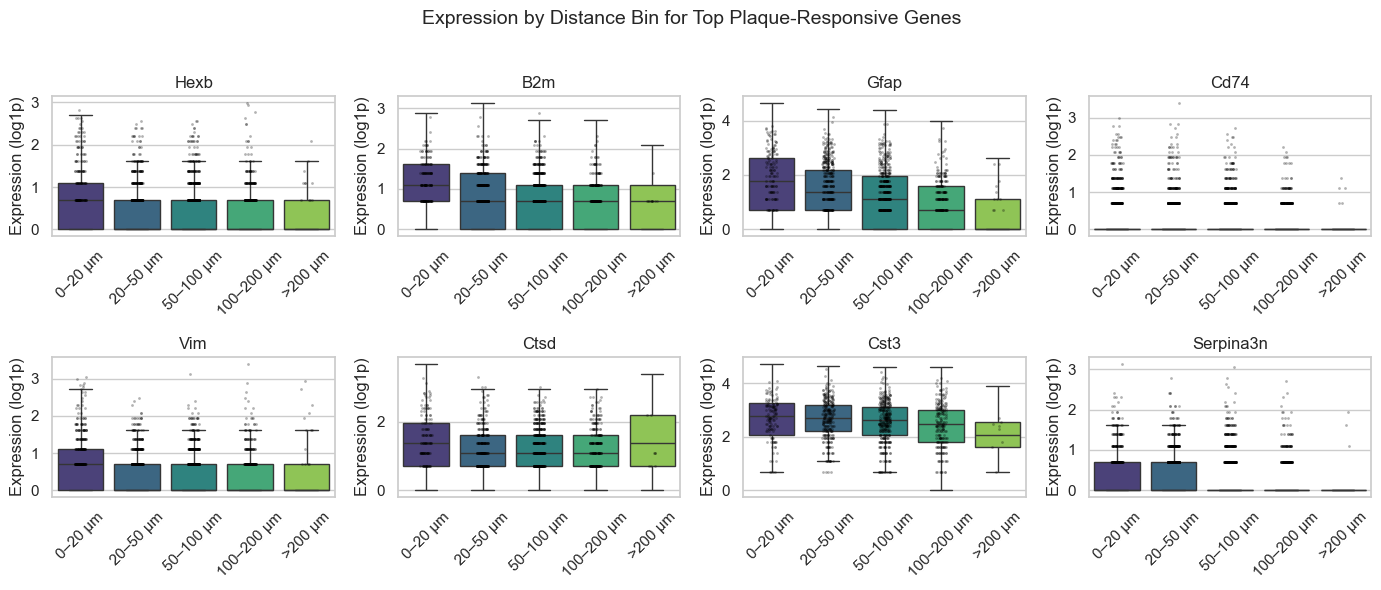

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

top_genes = anova_df.sort_values("qval").head(8)["gene"].tolist()

n_cols = 4
n_rows = int(np.ceil(len(top_genes) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3), sharey=False)
axes = axes.flatten()

for i, g in enumerate(top_genes):
    ax = axes[i]

    # --- Base boxplot
    sns.boxplot(
        data=combined_df_normalized,
        x="distance_bin",
        y=g,
        ax=ax,
        showfliers=False,
        palette="viridis",
    )

    # --- Overlay nonzero points for sparse genes (e.g., Cd74)
    nonzero = combined_df_normalized[combined_df_normalized[g] > 0]
    if len(nonzero) > 0:
        # sample up to 1000 points for speed
        sample = nonzero.sample(min(1000, len(nonzero)), random_state=0)
        sns.stripplot(
            data=sample, x="distance_bin", y=g, ax=ax, color="black", size=2, alpha=0.3, jitter=True
        )

    ax.set_title(g)
    ax.set_xlabel("")
    ax.set_ylabel("Expression (log1p)")
    ax.tick_params(axis="x", rotation=45)

# --- Figure formatting
fig.suptitle("Expression by Distance Bin for Top Plaque-Responsive Genes", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# --- merge continuous and categorical stats safely
summary_stats = reg_df.rename(columns={"pval": "pval_continuous", "qval": "qval_continuous"}).merge(
    anova_df.rename(columns={"pval": "anova_pval", "qval": "qval_anova"}), on="gene", how="left"
)

summary_stats = summary_stats.sort_values("slope")

# --- show top genes
cols_to_show = [
    c
    for c in ["gene", "slope", "pval_continuous", "qval_continuous", "anova_pval", "qval_anova"]
    if c in summary_stats.columns
]

logger.info("=== Top plaque-proximal genes (negative slope, smallest q-values) ===")
display(summary_stats.head(10)[cols_to_show])

logger.info("\n=== Least plaque-responsive genes (weakest or flat slopes) ===")
display(summary_stats.tail(5)[cols_to_show])

=== Top plaque-proximal genes (negative slope, smallest q-values) ===


,gene,slope,pval_continuous,qval_continuous,anova_pval,qval_anova
0,Gfap,-0.005313,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,Cst3,-0.002509,5.223421e-234,1.958783e-233,3.698604e-213,7.925580e-213
2,B2m,-0.002498,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,Vim,-0.001909,3.814466e-268,1.907233e-267,0.000000e+00,0.000000e+00
4,Apoe,-0.001712,8.565298e-109,1.284795e-108,1.770485e-118,2.213106e-118
5,Hexb,-0.001610,4.513449e-178,1.128362e-177,0.000000e+00,0.000000e+00
6,Ctsd,-0.001541,2.803488e-108,3.822938e-108,1.180158e-272,2.950396e-272
7,C4b,-0.001405,3.996474e-116,7.493388e-116,4.072558e-121,5.553488e-121
8,Serpina3n,-0.001157,9.263298e-142,1.984993e-141,2.291455e-189,4.296478e-189
9,Cd74,-0.000984,1.537710e-210,4.613131e-210,0.000000e+00,0.000000e+00



=== Least plaque-responsive genes (weakest or flat slopes) ===


,gene,slope,pval_continuous,qval_continuous,anova_pval,qval_anova
10,H2-K1,-0.000944,1.256338e-97,1.570422e-97,2.171029e-178,3.256544e-178
11,S100a6,-0.000868,5.654290e-116,9.423817e-116,1.638297e-184,2.730496e-184
12,Ifit3,-0.000530,1.935350e-46,2.233096e-46,1.942709e-61,2.081474e-61
13,Nrep,-0.000217,2.608811e-05,2.608811e-05,5.315834e-38,5.315834e-38
14,Cxcl10,-0.000152,2.229331e-41,2.388569e-41,1.604657e-69,1.851527e-69


Research Question 2 — Cell Type Frequency Gradients

Identify gene columns and build a clustering matrix

=== Distance to nearest plaque (µm) summary ===
count    56956.000000
mean        68.557212
std         44.787599
min          0.000000
25%         34.673606
50%         61.516188
75%         94.578283
max        457.648172
Name: nearest_plaque_dist, dtype: float64


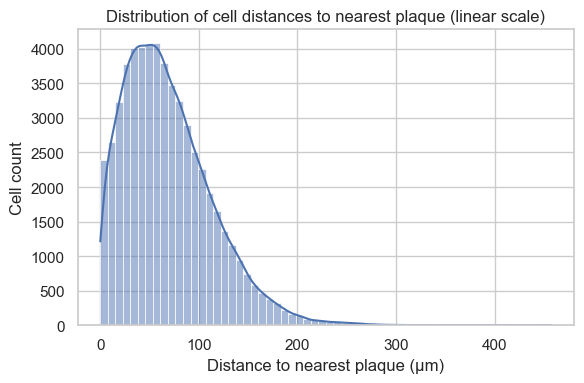

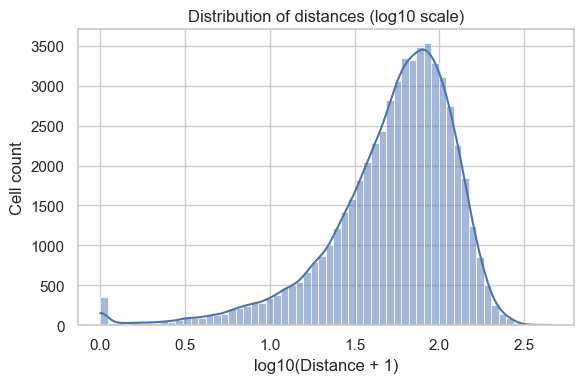

{'5%': 9.031616891188534, '25%': 34.67360612791328, '50% (median)': 61.516187627686264, '75%': 94.578282649893, '95%': 151.07227456103567}

=== Cell counts by proximity class ===
dist_bin_simple
intermediate (30–100 µm)    32665
distal (>100 µm)            12496
proximal (<30 µm)           11795
Name: count, dtype: int64


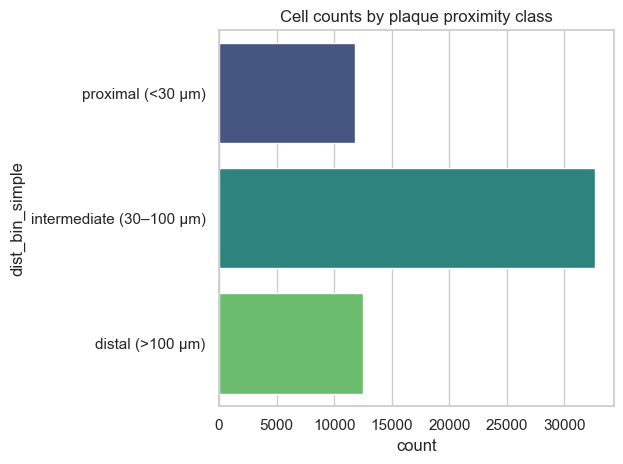

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = combined_df_normalized

# --- 1. Basic summary statistics
logger.info("=== Distance to nearest plaque (µm) summary ===")
logger.info(df["nearest_plaque_dist"].describe())

# --- 2. Histogram (linear scale)
plt.figure(figsize=(6, 4))
sns.histplot(df["nearest_plaque_dist"], bins=60, kde=True)
plt.xlabel("Distance to nearest plaque (µm)")
plt.ylabel("Cell count")
plt.title("Distribution of cell distances to nearest plaque (linear scale)")
plt.tight_layout()
plt.show()

# --- 3. Histogram (log scale)
plt.figure(figsize=(6, 4))
sns.histplot(np.log10(df["nearest_plaque_dist"] + 1), bins=60, kde=True)
plt.xlabel("log10(Distance + 1)")
plt.ylabel("Cell count")
plt.title("Distribution of distances (log10 scale)")
plt.tight_layout()
plt.show()

# --- 4. Quantiles and thresholds
q5, q25, q50, q75, q95 = np.percentile(df["nearest_plaque_dist"].dropna(), [5, 25, 50, 75, 95])
logger.info({"5%": q5, "25%": q25, "50% (median)": q50, "75%": q75, "95%": q95})

# --- 5. How many cells are proximal/intermediate/distal
PROX_THRESH = 30
DISTAL_THRESH = 100

bins = [0, PROX_THRESH, DISTAL_THRESH, np.inf]
labels = ["proximal (<30 µm)", "intermediate (30–100 µm)", "distal (>100 µm)"]
df["dist_bin_simple"] = pd.cut(
    df["nearest_plaque_dist"], bins=bins, labels=labels, include_lowest=True
)

logger.info("\n=== Cell counts by proximity class ===")
logger.info(df["dist_bin_simple"].value_counts())
sns.countplot(y="dist_bin_simple", data=df, order=labels, palette="viridis")
plt.title("Cell counts by plaque proximity class")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc

df = combined_df_normalized.copy()

# --- 1. Identify gene expression columns (numeric, excluding metadata)
meta_cols = {
    "cell_id",
    "x_centroid",
    "y_centroid",
    "transcript_counts",
    "control_probe_counts",
    "control_codeword_counts",
    "unassigned_codeword_counts",
    "total_counts",
    "cell_area",
    "nucleus_area",
    "distance_to_plaque",
    "nearest_plaque_dist",
    "nearest_plaque_center_dist",
    "inside_any_plaque",
    "nearest_plaque_id",
    "nearest_plaque_area",
    "distance_bin",
    "dist_bin_simple",
}
gene_cols = [c for c in df.columns if c not in meta_cols and np.issubdtype(df[c].dtype, np.number)]

logger.info(f"Detected {len(gene_cols)} gene columns")

# --- 2. Build AnnData object for Scanpy
adata = sc.AnnData(df[gene_cols].values)
adata.obs = df[["cell_id", "nearest_plaque_dist", "dist_bin_simple"]].copy()
adata.obs_names = df["cell_id"].astype(str)
adata.var_names = gene_cols

logger.info(adata)

Detected 347 gene columns
AnnData object with n_obs × n_vars = 56956 × 347
    obs: 'cell_id', 'nearest_plaque_dist', 'dist_bin_simple'


=== Step 4: PCA → Neighbors → Leiden Clustering ===
leiden
0     10573
1      6985
2      5836
3      4117
4      4056
5      3717
6      3121
7      2409
8      2184
9      2098
10     2033
11     1883
12     1671
13     1621
14     1173
15      955
16      789
17      615
18      480
19      464
20      176
Name: count, dtype: int64


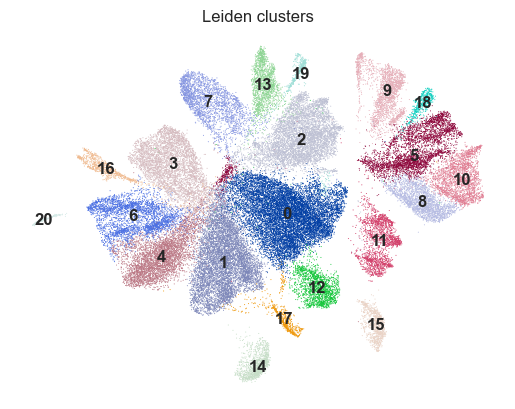

Added 'cluster_leiden' column to combined_df_2 ✅


In [ ]:
import scanpy as sc

logger.info("=== Step 4: PCA → Neighbors → Leiden Clustering ===")

# --- 1. Basic preprocessing
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=30, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)

# --- 2. Leiden clustering
sc.tl.leiden(adata, resolution=0.6, key_added="leiden")
logger.info(adata.obs["leiden"].value_counts())

# --- 3. UMAP for visualization
sc.tl.umap(adata)
sc.pl.umap(adata, color=["leiden"], legend_loc="on data", frameon=False, title="Leiden clusters")

# --- 4. Add cluster labels back to the main dataframe
combined_df_normalized["cluster_leiden"] = adata.obs["leiden"].values
logger.info("Added 'cluster_leiden' column to combined_df_normalized ✅")

=== Spatial distribution of Leiden clusters ===


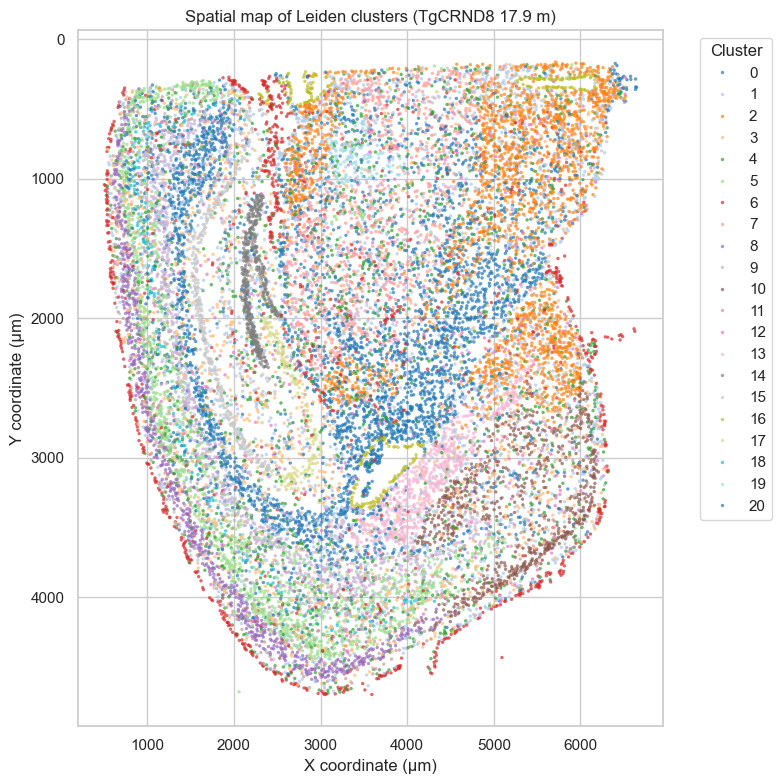

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

logger.info("=== Spatial distribution of Leiden clusters ===")

plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=combined_df_normalized.sample(20000, random_state=0),  # subsample for speed
    x="x_centroid",
    y="y_centroid",
    hue="cluster_leiden",
    palette="tab20",
    s=6,
    linewidth=0,
    alpha=0.7,
)
plt.gca().invert_yaxis()  # to match microscopy orientation
plt.title("Spatial map of Leiden clusters (TgCRND8 17.9 m)")
plt.xlabel("X coordinate (µm)")
plt.ylabel("Y coordinate (µm)")
plt.legend(bbox_to_anchor=(1.05, 1), title="Cluster", ncol=1)
plt.tight_layout()
plt.show()

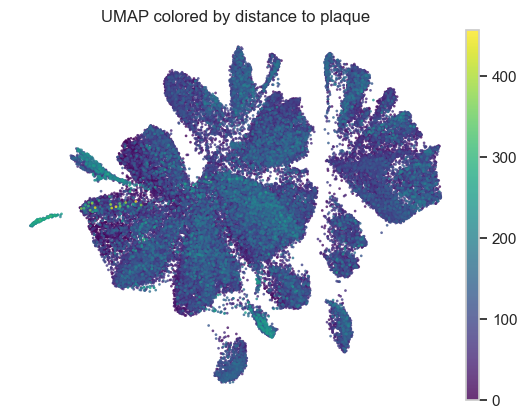

In [ ]:
sc.pl.umap(
    adata,
    color=["nearest_plaque_dist"],
    color_map="viridis",
    size=15,
    alpha=0.8,
    frameon=False,
    title="UMAP colored by distance to plaque",
)

=== Step 5 (Continuous): Cluster frequency vs. continuous distance ===


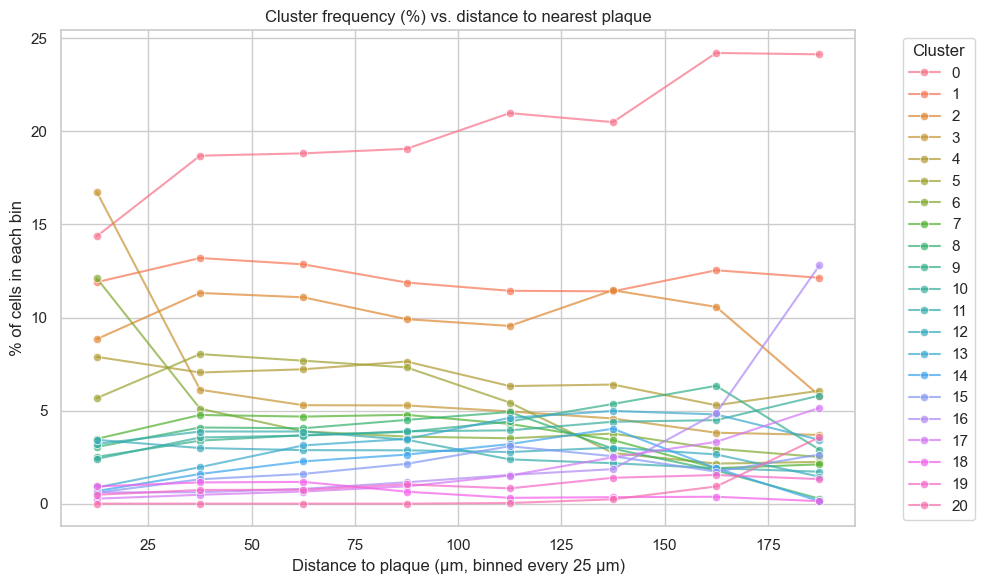

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

logger.info("=== Step 5 (Continuous): Cluster frequency vs. continuous distance ===")

# --- 1. Bin distances smoothly (e.g., 0–25 µm, 25–50 µm, ... up to ~200 µm)
max_dist = np.percentile(combined_df_normalized["nearest_plaque_dist"], 99)
bins = np.arange(0, max_dist + 25, 25)
combined_df_normalized["distance_bin_cont"] = pd.cut(
    combined_df_normalized["nearest_plaque_dist"], bins=bins
)

# --- 2. Compute cluster frequencies per distance bin
freq_df = (
    combined_df_normalized.groupby(["distance_bin_cont", "cluster_leiden"])
    .size()
    .reset_index(name="n_cells")
)

# Total cells per distance bin
totals = (
    combined_df_normalized["distance_bin_cont"]
    .value_counts()
    .rename_axis("distance_bin_cont")
    .reset_index(name="total_cells")
)
freq_df = freq_df.merge(totals, on="distance_bin_cont", how="left")
freq_df["pct"] = 100 * freq_df["n_cells"] / freq_df["total_cells"]

# --- 3. Convert bin labels to midpoints for plotting
freq_df["bin_mid"] = freq_df["distance_bin_cont"].apply(lambda x: x.mid if pd.notna(x) else np.nan)

# --- 4. Plot continuous trend per cluster
plt.figure(figsize=(10, 6))
sns.lineplot(data=freq_df, x="bin_mid", y="pct", hue="cluster_leiden", marker="o", alpha=0.7)
plt.title("Cluster frequency (%) vs. distance to nearest plaque")
plt.xlabel("Distance to plaque (µm, binned every 25 µm)")
plt.ylabel("% of cells in each bin")
plt.legend(bbox_to_anchor=(1.05, 1), title="Cluster", ncol=1)
plt.tight_layout()
plt.show()

In [ ]:
freq_df.head()

,distance_bin_cont,cluster_leiden,n_cells,total_cells,pct,bin_mid
0,"(0.0, 25.0]",0,1292,8990,14.371524,12.5
1,"(0.0, 25.0]",1,1070,8990,11.902113,12.5
2,"(0.0, 25.0]",2,795,8990,8.843159,12.5
3,"(0.0, 25.0]",3,1505,8990,16.740823,12.5
4,"(0.0, 25.0]",4,709,8990,7.886541,12.5


In [ ]:
import pandas as pd
from statsmodels.formula.api import logit

# Binary label: near vs far
combined_df_normalized["is_proximal"] = (
    combined_df_normalized["nearest_plaque_dist"] <= 30
).astype(int)

results = []
for cl in combined_df_normalized["cluster_leiden"].unique():
    df_cl = combined_df_normalized.copy()
    df_cl["in_cluster"] = (df_cl["cluster_leiden"] == cl).astype(int)
    model = logit("in_cluster ~ nearest_plaque_dist", data=df_cl).fit(disp=0)
    slope = model.params["nearest_plaque_dist"]
    pval = model.pvalues["nearest_plaque_dist"]
    results.append({"cluster": cl, "slope": slope, "pval": pval})

logit_df = pd.DataFrame(results)
logit_df["adj_pval"] = np.minimum(logit_df["pval"] * len(logit_df), 1.0)
display(logit_df.sort_values("pval").head(10))

,cluster,slope,pval,adj_pval
16,16,0.017737,6.317548e-196,1.326685e-194
9,3,-0.013184,2.302230e-179,4.834683e-178
11,17,0.017434,3.775873e-156,7.929334e-155
20,20,0.041735,7.536239e-156,1.582610e-154
7,6,-0.010674,8.635768e-100,1.813511e-98
15,13,0.007320,5.336404e-52,1.120645e-50
12,15,0.006346,8.504663e-24,1.785979e-22
1,5,-0.004028,7.016621e-23,1.473490e-21
6,0,0.002245,8.738884e-22,1.835166e-20
18,14,0.005523,2.709737e-21,5.690448e-20


Slope < 0	Cluster becomes more common near plaques (enriched proximally).
Slope > 0	Cluster becomes less common near plaques (enriched distally).

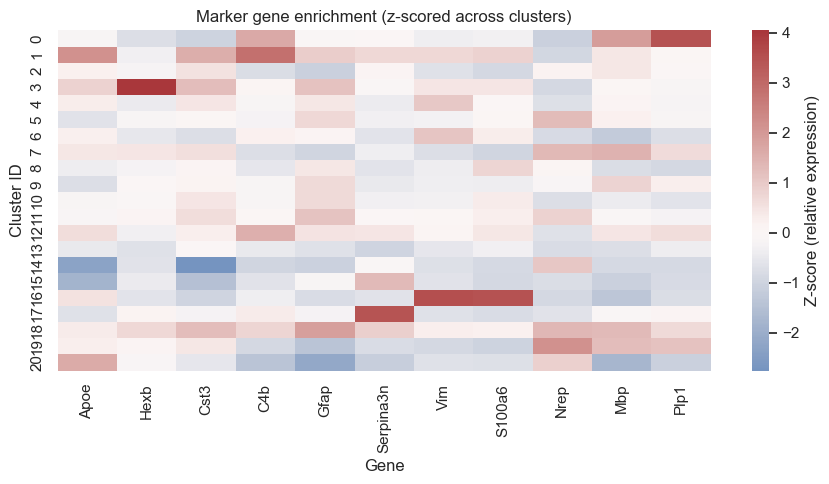

Apoe          1
Hexb          3
Cst3          1
C4b           1
Gfap         18
Serpina3n    17
Vim          16
S100a6       16
Nrep         19
Mbp           0
Plp1          0
Name: max_in_cluster, dtype: category
Categories (21, object): ['0', '1', '2', '3', ..., '17', '18', '19', '20']

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Reuse previous marker set
marker_genes = {
    "microglia": ["Apoe", "Hexb", "Cst3", "C4b"],
    "astrocyte": ["Gfap", "Serpina3n", "Vim", "S100a6"],
    "neuron": ["Nrep", "Snap25", "Rbfox3"],
    "oligodendrocyte": ["Mbp", "Plp1", "Cldn11"],
}

genes_to_check = [
    g for v in marker_genes.values() for g in v if g in combined_df_normalized.columns
]
expr = combined_df_normalized.groupby("cluster_leiden")[genes_to_check].mean()

# z-score per gene (across clusters)
expr_z = (expr - expr.mean(axis=0)) / expr.std(axis=0)

plt.figure(figsize=(9, 5))
sns.heatmap(expr_z, cmap="vlag", center=0, cbar_kws={"label": "Z-score (relative expression)"})
plt.title("Marker gene enrichment (z-scored across clusters)")
plt.xlabel("Gene")
plt.ylabel("Cluster ID")
plt.tight_layout()
plt.show()

# Identify cluster with highest z for each marker
top_z = expr_z.idxmax(axis=0).rename("max_in_cluster")
display(top_z)

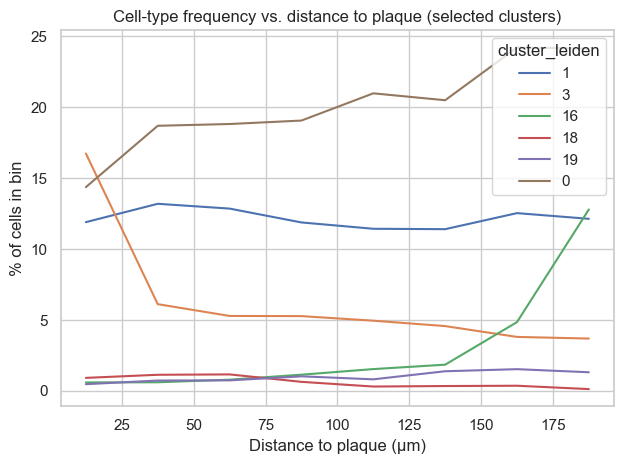

In [ ]:
sns.lineplot(
    data=freq_df,
    x="bin_mid",
    y="pct",
    hue="cluster_leiden",
    hue_order=["1", "3", "16", "18", "19", "0"],
)
plt.title("Cell-type frequency vs. distance to plaque (selected clusters)")
plt.xlabel("Distance to plaque (µm)")
plt.ylabel("% of cells in bin")
plt.tight_layout()
plt.show()

Research Question 3 — Relationship Between Gene Expression and Cell Type Composition

Step 1 – Quantify PIG expression and cell-type composition along distance